# Notebook 10 — Training Model Task 2: Sentimen Aspek Room

**Task 2** mengklasifikasikan sentimen ulasan yang membahas aspek **Room**.

| | |
|---|---|
| **Input** | Ulasan yang membahas Room (`Room_label=1`) |
| **Label** | `Room_sentiment` → 0=Negatif, 1=Positif |
| **Task** | Binary Classification |
| **Train** | `df_train_Task2_Room.csv` (3,066 baris) |
| **Test** | `df_test_Task2_Room.csv` (341 baris) |
| **K-Fold** | StratifiedKFold (menjaga proporsi Pos:Neg) |

---

**8 Skenario:**

| # | Arsitektur | Embedding | Preprocessing |
|---|-----------|-----------|---------------|
| 1 | CNN | Word2Vec | Non-Stemming |
| 2 | CNN | Word2Vec | Stemming |
| 3 | CNN | FastText | Non-Stemming |
| 4 | CNN | FastText | Stemming |
| 5 | BiLSTM | Word2Vec | Non-Stemming |
| 6 | BiLSTM | Word2Vec | Stemming |
| 7 | BiLSTM | FastText | Non-Stemming |
| 8 | BiLSTM | FastText | Stemming |

## 1. Instalasi & Import Library

In [ ]:
# StratifiedKFold sudah termasuk dalam scikit-learn
# tidak perlu install tambahan
!pip install gensim scikit-learn openpyxl --quiet

import os
import time
import pickle
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from gensim.models import Word2Vec, FastText

# StratifiedKFold: menjaga proporsi kelas di setiap fold (untuk binary classification)
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Bidirectional, LSTM, Dense, Dropout, Concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.metrics import AUC

tf.random.set_seed(42)
np.random.seed(42)

print('Library berhasil diimport.')
print(f'TensorFlow version: {tf.__version__}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 52.9 MB/s eta 0:00:00
Library berhasil diimport.
TensorFlow version: 2.19.0


## 2. Mount Google Drive & Konfigurasi Path

In [ ]:
drive.mount('/content/drive')

BASE_DIR    = '/content/drive/MyDrive/SKRIPSI_NAVY/'
SPLIT_DIR   = BASE_DIR + 'Dataset/Dataset_SplitData/'
TOKEN_DIR   = BASE_DIR + 'Dataset/Dataset_Tokenizer/'
EMBED_DIR   = BASE_DIR + 'Dataset/Dataset_WordEmbedding/'
OUTPUT_DIR  = BASE_DIR + 'Dataset/Dataset_Modelling/Task2_Room/'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output dir: {OUTPUT_DIR}')


Mounted at /content/drive
Output dir: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task2_Room/


## 3. Load Dataset, Tokenizer & Word Embedding


In [ ]:
# Load dataset Task 2 Room
df_train = pd.read_csv(SPLIT_DIR + 'df_train_Task2_Room.csv')
df_test  = pd.read_csv(SPLIT_DIR + 'df_test_Task2_Room.csv')

print(f'Train : {len(df_train):,} baris')
print(f'Test  : {len(df_test):,} baris')
print(f'Kolom : {df_train.columns.tolist()}')
print(f'\nDistribusi label Room_sentiment (train):')
vc = df_train['Room_sentiment'].value_counts()
for k, v in vc.items():
    label = 'Positif' if k == 1 else 'Negatif'
    print(f'  {label} ({k}): {v:,} ({v/len(df_train)*100:.1f}%)')


Train : 3,066 baris
Test  : 341 baris
Kolom : ['id', 'review_text_translated', 'review_non_stemmed', 'review_stemmed', 'Room', 'Hotel', 'Location', 'Service', 'Room_Pos', 'Room_Neg', 'Hotel_Pos', 'Hotel_Neg', 'Location_Pos', 'Location_Neg', 'Service_Pos', 'Service_Neg', 'Room_label', 'Hotel_label', 'Location_label', 'Service_label', 'Room_sentiment']

Distribusi label Room_sentiment (train):
  Negatif (0): 1,631 (53.2%)
  Positif (1): 1,435 (46.8%)


In [ ]:
# Load tokenizer (yang sudah di fit dari data train)
with open(TOKEN_DIR + 'tokenizer_nonstem.pkl', 'rb') as f:
    tokenizer_nonstem = pickle.load(f)
with open(TOKEN_DIR + 'tokenizer_stem.pkl', 'rb') as f:
    tokenizer_stem = pickle.load(f)

print(f'Vocab tokenizer nonstem : {len(tokenizer_nonstem.word_index):,} kata')
print(f'Vocab tokenizer stem    : {len(tokenizer_stem.word_index):,} kata')

Vocab tokenizer nonstem : 5,545 kata
Vocab tokenizer stem    : 3,811 kata


In [ ]:
# Load word embedding models (yang dilatih dari semua data)
model_w2v_nonstem = Word2Vec.load(EMBED_DIR + 'word2vec_non_stemmed.model')
model_w2v_stem    = Word2Vec.load(EMBED_DIR + 'word2vec_stemmed.model')
model_ft_nonstem  = FastText.load(EMBED_DIR + 'fasttext_non_stemmed.model')
model_ft_stem     = FastText.load(EMBED_DIR + 'fasttext_stemmed.model')

print('Word embedding berhasil diload:')
print(f'  W2V NonStem vocab : {len(model_w2v_nonstem.wv):,}')
print(f'  W2V Stem vocab    : {len(model_w2v_stem.wv):,}')
print(f'  FT  NonStem vocab : {len(model_ft_nonstem.wv):,}')
print(f'  FT  Stem vocab    : {len(model_ft_stem.wv):,}')

Word embedding berhasil diload:
  W2V NonStem vocab : 3,401
  W2V Stem vocab    : 2,468
  FT  NonStem vocab : 3,401
  FT  Stem vocab    : 2,468


## 4. Fungsi-Fungsi Utama


In [ ]:
# ============================================================
# FUNGSI 1: Buat Embedding Matrix
# Mapping dari indeks tokenizer → vektor Word2Vec/FastText
# ============================================================
def buat_embedding_matrix(embed_model, tokenizer):
    vocab_size   = len(tokenizer.word_index) + 1
    vector_size  = embed_model.vector_size
    emb_matrix   = np.zeros((vocab_size, vector_size))
    oov_count    = 0

    for word, idx in tokenizer.word_index.items():
        try:
            emb_matrix[idx] = embed_model.wv[word]
        except KeyError:
            oov_count += 1

    print(f'  Vocab tokenizer : {vocab_size:,} kata')
    print(f'  OOV             : {oov_count:,} kata tidak ditemukan di embedding')
    print(f'  Shape matrix    : {emb_matrix.shape}')
    return emb_matrix

print('Fungsi buat_embedding_matrix siap.')

Fungsi buat_embedding_matrix siap.


In [ ]:
# ============================================================
# FUNGSI 2: Bangun Model CNN (TextCNN Kim 2014)
#
# Menerapkan L2 regularization untuk mencegah overfitting:
# → kernel_regularizer=l2(0.001) di Conv1D dan Dense
# → model tidak bisa terlalu menghafal data train
# → train loss tidak turun terlalu agresif ke ~0.01
# ============================================================
def bangun_model_cnn(embedding_matrix, max_length, l2_strength=0.001):
    vocab_size, vector_size = embedding_matrix.shape

    inputs = Input(shape=(max_length,))
    x = Embedding(
        input_dim  = vocab_size,
        output_dim = vector_size,
        weights    = [embedding_matrix],
        trainable  = False
    )(inputs)

    # L2 di Conv1D: mencegah filter terlalu spesifik ke data train
    conv3 = GlobalMaxPooling1D()(Conv1D(100, kernel_size=3, activation='relu',
                                        kernel_regularizer=l2(l2_strength))(x))
    conv4 = GlobalMaxPooling1D()(Conv1D(100, kernel_size=4, activation='relu',
                                        kernel_regularizer=l2(l2_strength))(x))
    conv5 = GlobalMaxPooling1D()(Conv1D(100, kernel_size=5, activation='relu',
                                        kernel_regularizer=l2(l2_strength))(x))

    concat = Concatenate()([conv3, conv4, conv5])
    x = Dropout(0.5)(concat)

    # L2 di Dense: mencegah neuron terlalu bergantung pada fitur tertentu
    x = Dense(64, activation='relu', kernel_regularizer=l2(l2_strength))(x)
    x = Dropout(0.5)(x)

    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer = Adam(learning_rate=0.001),
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy', AUC(name='auc')]
    )
    return model

print('Fungsi bangun_model_cnn siap (dengan L2=0.001).')


Fungsi bangun_model_cnn siap (dengan L2=0.001).


In [ ]:
# ============================================================
# FUNGSI 3: Bangun Model BiLSTM
#
# Menerapkan L2 regularization:
# → kernel_regularizer=l2(0.001) di Dense
# → BiLSTM sudah punya dropout internal (0.2) sehingga L2 hanya ditambah di Dense layer
# ============================================================
def bangun_model_bilstm(embedding_matrix, max_length, l2_strength=0.001):
    vocab_size, vector_size = embedding_matrix.shape

    inputs = Input(shape=(max_length,))
    x = Embedding(
        input_dim  = vocab_size,
        output_dim = vector_size,
        weights    = [embedding_matrix],
        trainable  = False
    )(inputs)

    # BiLSTM sudah punya regularisasi internal: dropout=0.2 dan recurrent_dropout=0.2
    x = Bidirectional(LSTM(
        64,
        dropout           = 0.2,
        recurrent_dropout = 0.2
    ))(x)

    x = Dropout(0.5)(x)

    # L2 di Dense layer
    x = Dense(64, activation='relu', kernel_regularizer=l2(l2_strength))(x)
    x = Dropout(0.5)(x)

    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer = Adam(learning_rate=0.001),
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy', AUC(name='auc')]
    )
    return model

print('Fungsi bangun_model_bilstm siap (dengan L2=0.001).')


Fungsi bangun_model_bilstm siap (dengan L2=0.001).


In [ ]:
# ============================================================
# CEK ARSITEKTUR MODEL — Summary CNN & BiLSTM
# ============================================================

MAX_LENGTH = 100

# Pakai embedding matrix skenario 1 (nonstem) untuk preview
print('Membuat embedding matrix untuk preview...')
emb_preview = buat_embedding_matrix(model_w2v_nonstem, tokenizer_nonstem)

# ── Summary CNN ──
print('\n' + '='*65)
print('  ARSITEKTUR CNN')
print('='*65)
cnn_preview = bangun_model_cnn(emb_preview, MAX_LENGTH)
cnn_preview.summary()
del cnn_preview

# ── Summary BiLSTM ──
print('\n' + '='*65)
print('  ARSITEKTUR BiLSTM')
print('='*65)
bilstm_preview = bangun_model_bilstm(emb_preview, MAX_LENGTH)
bilstm_preview.summary()
del bilstm_preview

del emb_preview
print('\n✅ Arsitektur sudah dicek, siap training!')

Membuat embedding matrix untuk preview...
  Vocab tokenizer : 5,546 kata
  OOV             : 2,156 kata tidak ditemukan di embedding
  Shape matrix    : (5546, 100)

  ARSITEKTUR CNN


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 100)  │    554,600 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 98, 100)   │     30,100 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 97, 100)   │     40,100 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 96, 100)   │     50,100 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 100)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 300)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 300)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     19,264 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 694,229 (2.65 MB)

 Trainable params: 139,629 (545.43 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 100, 100)       │       554,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 647,401 (2.47 MB)

 Trainable params: 92,801 (362.50 KB)

 Non-trainable params: 554,600 (2.12 MB)


✅ Arsitektur sudah dicek, siap training!


In [ ]:
# ============================================================
# FUNGSI 4: Hitung Metrik Binary Classification
#
# Berbeda dari Task 1 (multilabel):
# → accuracy biasa (bukan rata-rata per label)
# → tidak ada hamming loss, subset accuracy
# → AUC biasa (bukan multi_label=True)
# ============================================================
def hitung_metrik_binary(y_true, y_pred_prob):
    y_pred = (y_pred_prob >= 0.5).astype(int).flatten()
    y_true = y_true.flatten()

    acc       = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall    = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1        = f1_score(y_true, y_pred, average='macro', zero_division=0)

    try:
        auc = roc_auc_score(y_true, y_pred_prob.flatten())
    except:
        auc = 0.0

    return {
        'accuracy'        : acc,
        'precision_macro' : precision,
        'recall_macro'    : recall,
        'f1_macro'        : f1,
        'auc'             : auc,
    }

print('Fungsi hitung_metrik_binary siap.')

Fungsi hitung_metrik_binary siap.


In [ ]:
# ============================================================
# FUNGSI 5: Catat Resource (RAM & CPU)
# ============================================================
def catat_resource():
    proses     = psutil.Process(os.getpid())
    ram_mb     = proses.memory_info().rss / 1024 / 1024
    ram_total  = psutil.virtual_memory().total / 1024 / 1024
    ram_pct    = (ram_mb / ram_total) * 100
    cpu_pct    = psutil.cpu_percent(interval=1)
    return ram_mb, ram_pct, cpu_pct

print('Fungsi catat_resource siap.')

Fungsi catat_resource siap.


In [ ]:
# ============================================================
# FUNGSI 6: Plot Training History (Loss & Accuracy per Epoch)
# ============================================================
def plot_training_history(history_list, nama_skenario, output_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for fold_idx, history in enumerate(history_list):
        label = f'Fold {fold_idx+1}'
        axes[0].plot(history['loss'],     linestyle='-',  label=f'{label} train')
        axes[0].plot(history['val_loss'], linestyle='--', label=f'{label} val')
        axes[1].plot(history['accuracy'],      linestyle='-',  label=f'{label} train')
        axes[1].plot(history['val_accuracy'],  linestyle='--', label=f'{label} val')

    axes[0].set_title('Loss per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend(fontsize=7)
    axes[0].spines[['top','right']].set_visible(False)

    axes[1].set_title('Accuracy per Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0.5, 1.02)
    axes[1].legend(fontsize=7)
    axes[1].spines[['top','right']].set_visible(False)

    plt.suptitle(f'Training History — {nama_skenario}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

print('Fungsi plot_training_history siap.')

Fungsi plot_training_history siap.


## 5. Persiapan Data


In [ ]:
MAX_LENGTH = 100
LABEL_COL  = 'Room_sentiment'

# Label binary
y_train = df_train[LABEL_COL].values
y_test  = df_test[LABEL_COL].values

# Tokenisasi NonStem
X_train_nonstem = pad_sequences(
    tokenizer_nonstem.texts_to_sequences(df_train['review_non_stemmed']),
    maxlen=MAX_LENGTH, padding='post', truncating='post'
)
X_test_nonstem = pad_sequences(
    tokenizer_nonstem.texts_to_sequences(df_test['review_non_stemmed']),
    maxlen=MAX_LENGTH, padding='post', truncating='post'
)

# Tokenisasi Stem
X_train_stem = pad_sequences(
    tokenizer_stem.texts_to_sequences(df_train['review_stemmed']),
    maxlen=MAX_LENGTH, padding='post', truncating='post'
)
X_test_stem = pad_sequences(
    tokenizer_stem.texts_to_sequences(df_test['review_stemmed']),
    maxlen=MAX_LENGTH, padding='post', truncating='post'
)

print(f'X_train_nonstem : {X_train_nonstem.shape}')
print(f'X_train_stem    : {X_train_stem.shape}')
print(f'y_train         : {y_train.shape}')
print(f'y_test          : {y_test.shape}')

X_train_nonstem : (3066, 100)
X_train_stem    : (3066, 100)
y_train         : (3066,)
y_test          : (341,)


In [ ]:
skenario_list = [
    # ── CNN ──
    {'nama': 'Skenario1_CNN_W2V_NonStem',    'arsitektur': 'cnn',    'embed_model': model_w2v_nonstem, 'tokenizer': tokenizer_nonstem, 'X_train': X_train_nonstem, 'X_test': X_test_nonstem},
    {'nama': 'Skenario2_CNN_W2V_Stem',       'arsitektur': 'cnn',    'embed_model': model_w2v_stem,    'tokenizer': tokenizer_stem,    'X_train': X_train_stem,    'X_test': X_test_stem},
    {'nama': 'Skenario3_CNN_FT_NonStem',     'arsitektur': 'cnn',    'embed_model': model_ft_nonstem,  'tokenizer': tokenizer_nonstem, 'X_train': X_train_nonstem, 'X_test': X_test_nonstem},
    {'nama': 'Skenario4_CNN_FT_Stem',        'arsitektur': 'cnn',    'embed_model': model_ft_stem,     'tokenizer': tokenizer_stem,    'X_train': X_train_stem,    'X_test': X_test_stem},
    # ── BiLSTM ──
    {'nama': 'Skenario5_BiLSTM_W2V_NonStem', 'arsitektur': 'bilstm', 'embed_model': model_w2v_nonstem, 'tokenizer': tokenizer_nonstem, 'X_train': X_train_nonstem, 'X_test': X_test_nonstem},
    {'nama': 'Skenario6_BiLSTM_W2V_Stem',    'arsitektur': 'bilstm', 'embed_model': model_w2v_stem,    'tokenizer': tokenizer_stem,    'X_train': X_train_stem,    'X_test': X_test_stem},
    {'nama': 'Skenario7_BiLSTM_FT_NonStem',  'arsitektur': 'bilstm', 'embed_model': model_ft_nonstem,  'tokenizer': tokenizer_nonstem, 'X_train': X_train_nonstem, 'X_test': X_test_nonstem},
    {'nama': 'Skenario8_BiLSTM_FT_Stem',     'arsitektur': 'bilstm', 'embed_model': model_ft_stem,     'tokenizer': tokenizer_stem,    'X_train': X_train_stem,    'X_test': X_test_stem},
]

print(f'Total skenario: {len(skenario_list)}')
for s in skenario_list:
    print(f"  {s['nama']}")


Total skenario: 8
  Skenario1_CNN_W2V_NonStem
  Skenario2_CNN_W2V_Stem
  Skenario3_CNN_FT_NonStem
  Skenario4_CNN_FT_Stem
  Skenario5_BiLSTM_W2V_NonStem
  Skenario6_BiLSTM_W2V_Stem
  Skenario7_BiLSTM_FT_NonStem
  Skenario8_BiLSTM_FT_Stem


## 7. Training 8 Skenario dengan Stratified K-Fold

**Alur per skenario:**
1. Buat embedding matrix
2. StratifiedKFold 5 fold → menjaga proporsi Positif:Negatif di tiap fold
3. Training + evaluasi per fold (tampilkan metrik, CM, ROC)
4. Simpan metrics, history, prediksi ke CSV
5. Simpan model fold terakhir (.h5)
6. Plot training history semua fold
7. Rekap rata-rata ± std dari 5 fold


In [ ]:
# ============================================================
# SETUP TRAINING
# ============================================================
K_FOLD     = 5
BATCH_SIZE = 32
MAX_EPOCH  = 20
rekap_semua = []
skf = StratifiedKFold(n_splits=K_FOLD, shuffle=True, random_state=42)

# ============================================================
# CUSTOM CALLBACK — Catat Waktu per Epoch
# ============================================================
class WaktuCallback(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.waktu_per_epoch = []

    def on_epoch_begin(self, epoch, logs=None):
        self._epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        self.waktu_per_epoch.append(time.time() - self._epoch_start)

# ============================================================
# FUNGSI TRAINING 1 SKENARIO
# ============================================================
def jalankan_skenario(skenario):
    nama        = skenario['nama']
    arsitektur  = skenario['arsitektur']
    embed_model = skenario['embed_model']
    tokenizer   = skenario['tokenizer']
    X_train_s   = skenario['X_train']
    X_test_s    = skenario['X_test']
    skenario_dir = OUTPUT_DIR + nama + '/'
    os.makedirs(skenario_dir, exist_ok=True)

    # Skip kalau model sudah ada
    model_path = skenario_dir + 'model.h5'
    if os.path.exists(model_path):
        print(f'[SKIP] {nama} — model sudah ada')
        return

    print(f"\n{'='*65}")
    print(f'  Training: {nama}')
    print(f"{'='*65}")
    print('  Membuat embedding matrix...')
    embedding_matrix = buat_embedding_matrix(embed_model, tokenizer)

    metrics_semua_fold  = []
    history_semua_fold  = []
    prediksi_semua_fold = []

    for fold_ke, (train_idx, val_idx) in enumerate(
            skf.split(X_train_s, y_train), start=1):

        print(f'\n  ── Fold {fold_ke}/{K_FOLD} ──')

        early_stopping = EarlyStopping(
            monitor              = 'val_loss',
            patience             = 2,
            restore_best_weights = True,
            verbose              = 0
        )
        waktu_cb = WaktuCallback()  # ← callback waktu per epoch

        X_fold_train = X_train_s[train_idx]
        X_fold_val   = X_train_s[val_idx]
        y_fold_train = y_train[train_idx]
        y_fold_val   = y_train[val_idx]

        pos = y_fold_train.sum()
        neg = len(y_fold_train) - pos
        print(f'  Distribusi train: Pos={pos}, Neg={neg}')

        if arsitektur == 'cnn':
            model = bangun_model_cnn(embedding_matrix, MAX_LENGTH)
        else:
            model = bangun_model_bilstm(embedding_matrix, MAX_LENGTH)

        # ── Catat resource sebelum training ──
        ram_sebelum, ram_pct_sebelum, _ = catat_resource()  # ← 3 nilai
        waktu_train_mulai = time.time()

        history = model.fit(
            X_fold_train, y_fold_train,
            validation_data = (X_fold_val, y_fold_val),
            epochs          = MAX_EPOCH,
            batch_size      = BATCH_SIZE,
            callbacks       = [early_stopping, waktu_cb],  # ← tambah waktu_cb
            verbose         = 1
        )

        waktu_training  = time.time() - waktu_train_mulai

        waktu_inf_mulai = time.time()
        y_pred_prob     = model.predict(X_fold_val, verbose=0)
        waktu_inference = time.time() - waktu_inf_mulai

        # ── Catat resource sesudah training ──
        ram_sesudah, ram_pct, cpu_pct = catat_resource()  # ← 3 nilai

        # ── Hitung waktu per epoch dan per step ──
        ep_selesai      = len(history.history['loss'])
        n_steps         = max(1, len(X_fold_train) // BATCH_SIZE)
        time_per_epoch  = round(
            sum(waktu_cb.waktu_per_epoch) / len(waktu_cb.waktu_per_epoch), 2
        ) if waktu_cb.waktu_per_epoch else 0
        time_per_step   = round(time_per_epoch / n_steps, 4)

        # ── Kumpulkan metrik ──
        metrik = hitung_metrik_binary(y_fold_val, y_pred_prob)
        metrik['fold']            = fold_ke
        metrik['waktu_training']  = round(waktu_training, 2)
        metrik['waktu_inference'] = round(waktu_inference, 4)
        metrik['time_per_epoch']  = time_per_epoch   # ← baru
        metrik['time_per_step']   = time_per_step    # ← baru
        metrik['ram_mb']          = round(ram_sesudah, 1)
        metrik['ram_pct']         = round(ram_pct, 2)  # ← baru
        metrik['cpu_pct']         = round(cpu_pct, 1)
        metrik['epoch_berhenti']  = ep_selesai
        metrics_semua_fold.append(metrik)

        df_history_fold = pd.DataFrame(history.history)
        df_history_fold['fold']  = fold_ke
        df_history_fold['epoch'] = range(1, len(df_history_fold)+1)
        history_semua_fold.append(df_history_fold)

        y_pred_biner = (y_pred_prob >= 0.5).astype(int).flatten()
        df_pred_fold = df_train.iloc[val_idx][
            ['id', 'review_non_stemmed', LABEL_COL]
        ].copy().reset_index(drop=True)
        df_pred_fold['pred_sentiment'] = y_pred_biner
        df_pred_fold['prob_positif']   = y_pred_prob.flatten().round(4)
        df_pred_fold['fold']           = fold_ke
        prediksi_semua_fold.append(df_pred_fold)

        # ── Print ringkasan fold ──
        print(f'\n  ┌─ Hasil Fold {fold_ke} ─────────────────────────────')
        print(f"  │  Epoch berhenti  : {metrik['epoch_berhenti']}")
        print(f"  │  Precision Macro : {metrik['precision_macro']:.4f}")
        print(f"  │  Recall Macro    : {metrik['recall_macro']:.4f}")
        print(f"  │  F1 Macro        : {metrik['f1_macro']:.4f}")
        print(f"  │  Accuracy        : {metrik['accuracy']:.4f}")
        print(f"  │  AUC             : {metrik['auc']:.4f}")
        print(f'  ├─ Resource ────────────────────────────────────')
        print(f"  │  Waktu Training  : {waktu_training:.2f} detik")
        print(f"  │  Waktu/Epoch     : {time_per_epoch:.2f} detik/epoch")
        print(f"  │  Waktu/Step      : {time_per_step:.4f} detik/step")
        print(f"  │  Waktu Inference : {waktu_inference:.4f} detik")
        print(f"  │  RAM Usage       : {ram_sesudah:.1f} MB ({ram_pct:.1f}%)")
        print(f"  └─ CPU Usage       : {cpu_pct:.1f} %")

        # ── Classification Report ──
        print(f'\n  Classification Report Fold {fold_ke}:')
        print(classification_report(
            y_fold_val, y_pred_biner,
            target_names=['Negatif', 'Positif'],
            zero_division=0
        ))

        # ── Confusion Matrix ──
        fig_cm, ax_cm = plt.subplots(figsize=(5, 4))
        cm = confusion_matrix(y_fold_val, y_pred_biner)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
                    xticklabels=['Negatif', 'Positif'],
                    yticklabels=['Negatif', 'Positif'])
        ax_cm.set_title(f'Confusion Matrix — {nama} Fold {fold_ke}',
                        fontweight='bold')
        ax_cm.set_xlabel('Prediksi')
        ax_cm.set_ylabel('Aktual')
        plt.tight_layout()
        plt.savefig(skenario_dir + f'cm_fold{fold_ke}.png',
                    dpi=120, bbox_inches='tight')
        plt.show()
        plt.close()

        # ── ROC Curve ──
        fig_roc, ax_roc = plt.subplots(figsize=(6, 5))
        fpr, tpr, _ = roc_curve(y_fold_val, y_pred_prob.flatten())
        ax_roc.plot(fpr, tpr, color='#3498db',
                    label=f"AUC = {metrik['auc']:.3f}")
        ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
        ax_roc.set_xlabel('False Positive Rate')
        ax_roc.set_ylabel('True Positive Rate')
        ax_roc.set_title(f'ROC Curve — {nama} Fold {fold_ke}',
                         fontweight='bold')
        ax_roc.legend(loc='lower right')
        ax_roc.spines[['top', 'right']].set_visible(False)
        plt.tight_layout()
        plt.savefig(skenario_dir + f'roc_fold{fold_ke}.png',
                    dpi=120, bbox_inches='tight')
        plt.show()
        plt.close()

    # ── Selesai 5 fold — Simpan hasil ──
    pd.DataFrame(metrics_semua_fold).to_csv(
        skenario_dir + 'metrics_per_fold.csv', index=False)
    pd.concat(history_semua_fold, ignore_index=True).to_csv(
        skenario_dir + 'history_per_fold.csv', index=False)
    pd.concat(prediksi_semua_fold, ignore_index=True).to_csv(
        skenario_dir + 'predictions_all_folds.csv', index=False)

    # Simpan model fold terakhir
    model.save(model_path)
    print(f'\n  Model disimpan: {model_path}')

    # Plot training history
    plot_training_history(
        [h.to_dict('list') for h in history_semua_fold],
        nama,
        skenario_dir + 'training_history.png'
    )

    # ── Rekap rata-rata dan std ──
    df_metrics  = pd.DataFrame(metrics_semua_fold)
    metrik_cols = [
        'accuracy', 'precision_macro', 'recall_macro',
        'f1_macro', 'auc',
        'waktu_training', 'waktu_inference',
        'time_per_epoch', 'time_per_step',   # ← baru
        'ram_mb', 'ram_pct', 'cpu_pct',      # ← ram_pct baru
        'epoch_berhenti'
    ]
    rekap = {'skenario': nama, 'arsitektur': arsitektur}
    for col in metrik_cols:
        if col in df_metrics.columns:
            rekap[f'avg_{col}'] = round(df_metrics[col].mean(), 4)
            rekap[f'std_{col}'] = round(df_metrics[col].std(),  4)
    rekap_semua.append(rekap)

    # Simpan rekap langsung
    pd.DataFrame(rekap_semua).to_csv(
        OUTPUT_DIR + 'rekap_Task2_semua_skenario.csv', index=False)

    print(f"\n  ╔═ SELESAI: {nama}")
    print(f"  ║  avg Precision  : {rekap['avg_precision_macro']:.4f} ± {rekap['std_precision_macro']:.4f}")
    print(f"  ║  avg Recall     : {rekap['avg_recall_macro']:.4f} ± {rekap['std_recall_macro']:.4f}")
    print(f"  ║  avg F1 Macro   : {rekap['avg_f1_macro']:.4f} ± {rekap['std_f1_macro']:.4f}")
    print(f"  ║  avg Accuracy   : {rekap['avg_accuracy']:.4f} ± {rekap['std_accuracy']:.4f}")
    print(f"  ║  avg AUC        : {rekap['avg_auc']:.4f} ± {rekap['std_auc']:.4f}")
    print(f"  ║  avg RAM        : {rekap['avg_ram_mb']:.1f} MB ({rekap['avg_ram_pct']:.1f}%)")
    print(f"  ║  avg CPU        : {rekap['avg_cpu_pct']:.1f} %")
    print(f"  ║  avg Waktu      : {rekap['avg_waktu_training']:.2f} detik/fold")
    print(f"  ║  avg T/Epoch    : {rekap['avg_time_per_epoch']:.2f} detik/epoch")
    print(f"  ║  avg T/Step     : {rekap['avg_time_per_step']:.4f} detik/step")
    print(f"  ╚══════════════════════════════════════════════════")

print('Setup selesai.')

Setup selesai.



  Training: Skenario1_CNN_W2V_NonStem
  Membuat embedding matrix...
  Vocab tokenizer : 5,546 kata
  OOV             : 2,156 kata tidak ditemukan di embedding
  Shape matrix    : (5546, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1148, Neg=1304
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.8336 - auc: 0.9153 - loss: 0.7578 - val_accuracy: 0.9609 - val_auc: 0.9956 - val_loss: 0.4812
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9470 - auc: 0.9849 - loss: 0.4982 - val_accuracy: 0.9642 - val_auc: 0.9979 - val_loss: 0.4023
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.9617 - auc: 0.9904 - loss: 0.4160 - val_accuracy: 0.9788 - val_auc: 0.9986 - val_loss: 0.3361
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.9735 - auc: 0.9939 - loss: 0.3477 - val_accuracy: 0.9821 - val_auc: 0.9991 - val_loss: 0.2914
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.9759 - auc: 0.9963 - loss: 0.3050 - val_accuracy: 

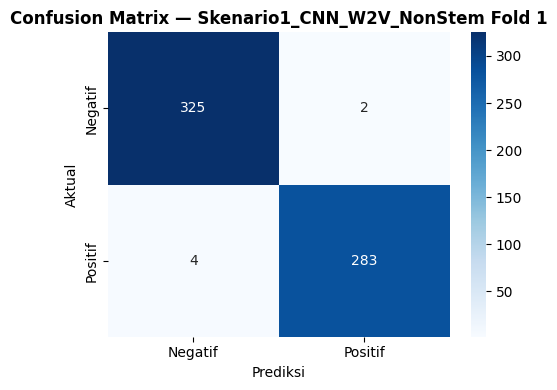

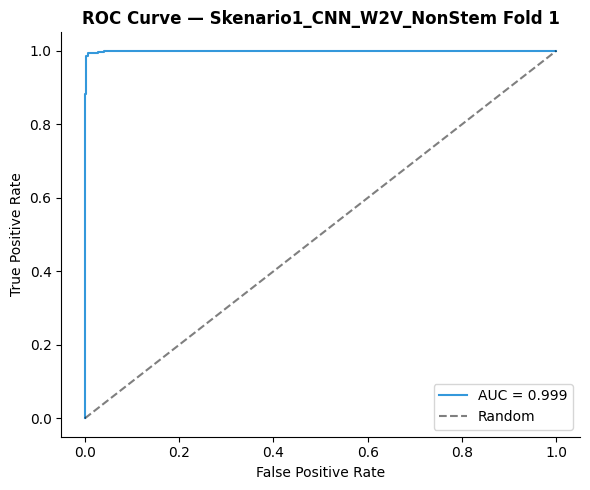


  ── Fold 2/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step - accuracy: 0.8475 - auc: 0.9281 - loss: 0.7315 - val_accuracy: 0.9527 - val_auc: 0.9896 - val_loss: 0.4977
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.9474 - auc: 0.9821 - loss: 0.5017 - val_accuracy: 0.9690 - val_auc: 0.9931 - val_loss: 0.4120
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9560 - auc: 0.9916 - loss: 0.4081 - val_accuracy: 0.9772 - val_auc: 0.9948 - val_loss: 0.3549
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9666 - auc: 0.9929 - loss: 0.3569 - val_accuracy: 0.9755 - val_auc: 0.9953 - val_loss: 0.3167
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.9796 - auc: 0.9957 - loss: 0.2955 - val_accuracy: 0.9723 - val_auc: 0.9961 - val_loss: 0.2860
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9837 - auc: 0.9967 - loss: 0.2566 - val_accuracy: 0.9804 - val_auc: 0.9953 - val_lo

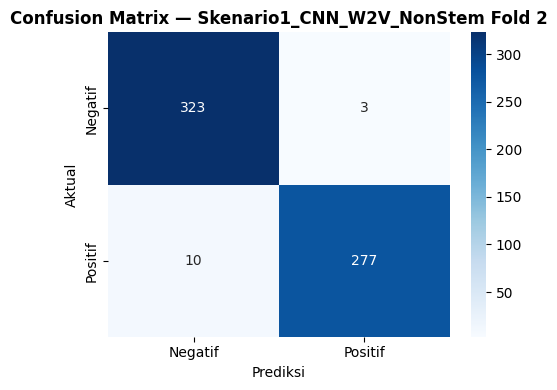

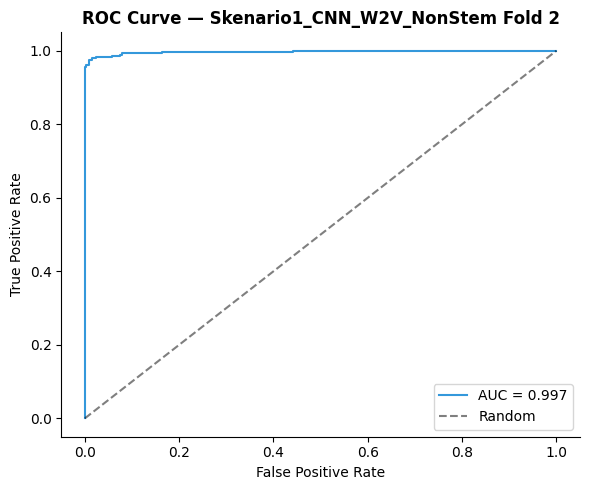


  ── Fold 3/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.8373 - auc: 0.9179 - loss: 0.7518 - val_accuracy: 0.9478 - val_auc: 0.9827 - val_loss: 0.5200
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.9389 - auc: 0.9815 - loss: 0.5100 - val_accuracy: 0.9641 - val_auc: 0.9891 - val_loss: 0.4251
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9617 - auc: 0.9930 - loss: 0.4038 - val_accuracy: 0.9739 - val_auc: 0.9909 - val_loss: 0.3666
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9698 - auc: 0.9951 - loss: 0.3462 - val_accuracy: 0.9772 - val_auc: 0.9919 - val_loss: 0.3264
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.9755 - auc: 0.9970 - loss: 0.2961 - val_accuracy: 0.9755 - val_auc: 0.9929 - val_loss: 0.2921
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9796 - auc: 0.9977 - loss: 0.2611 - val_accuracy: 0.9772 - val_auc: 0.9929 - val_lo

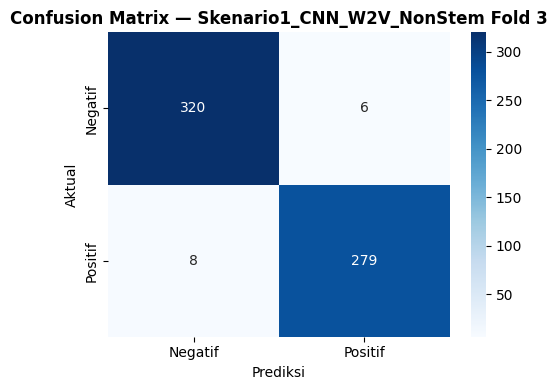

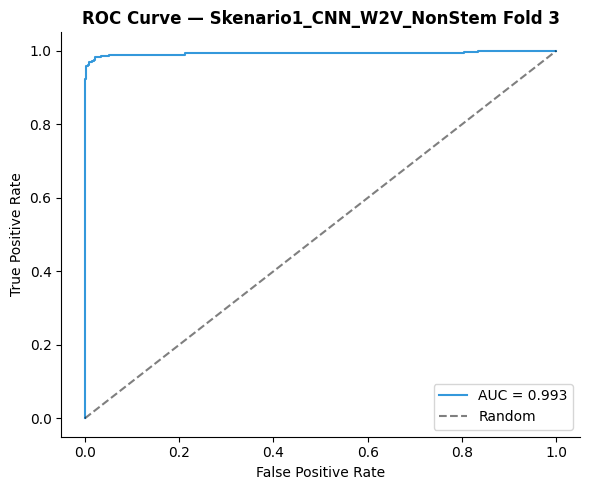


  ── Fold 4/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.8365 - auc: 0.9157 - loss: 0.7522 - val_accuracy: 0.9299 - val_auc: 0.9818 - val_loss: 0.5464
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.9511 - auc: 0.9843 - loss: 0.4889 - val_accuracy: 0.9527 - val_auc: 0.9902 - val_loss: 0.4435
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.9625 - auc: 0.9934 - loss: 0.3914 - val_accuracy: 0.9641 - val_auc: 0.9934 - val_loss: 0.3702
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.9772 - auc: 0.9929 - loss: 0.3373 - val_accuracy: 0.9657 - val_auc: 0.9938 - val_loss: 0.3282
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.9776 - auc: 0.9958 - loss: 0.2870 - val_accuracy: 0.9641 - val_auc: 0.9949 - val_loss: 0.2966
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.9800 - auc: 0.9964 - loss: 0.2478 - val_accuracy: 0.9657 - val_auc: 0.9961 - val_lo

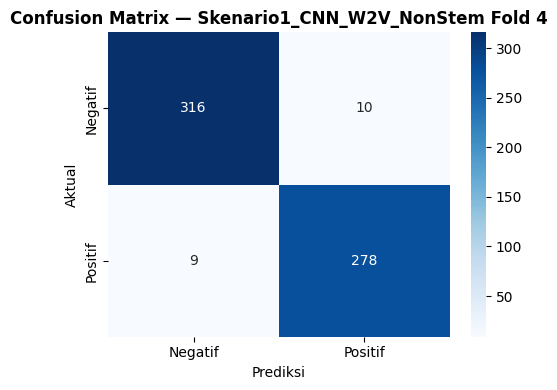

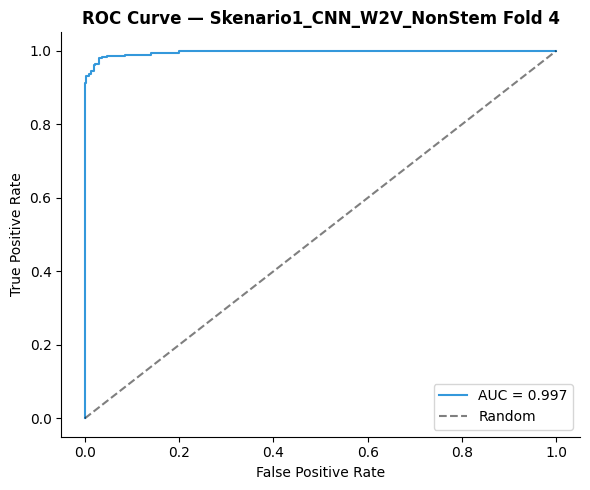


  ── Fold 5/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.8418 - auc: 0.9215 - loss: 0.7412 - val_accuracy: 0.9511 - val_auc: 0.9915 - val_loss: 0.4850
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.9470 - auc: 0.9833 - loss: 0.4983 - val_accuracy: 0.9690 - val_auc: 0.9952 - val_loss: 0.4023
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.9666 - auc: 0.9922 - loss: 0.3985 - val_accuracy: 0.9706 - val_auc: 0.9962 - val_loss: 0.3516
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9698 - auc: 0.9942 - loss: 0.3419 - val_accuracy: 0.9723 - val_auc: 0.9957 - val_loss: 0.3125
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9792 - auc: 0.9958 - loss: 0.2910 - val_accuracy: 0.9755 - val_auc: 0.9954 - val_loss: 0.2777
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.9849 - auc: 0.9968 - loss: 0.2488 - val_accuracy: 0.9755 - val_auc: 0.9959 - val_lo

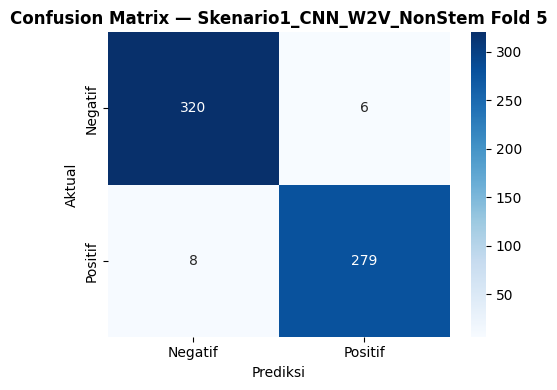

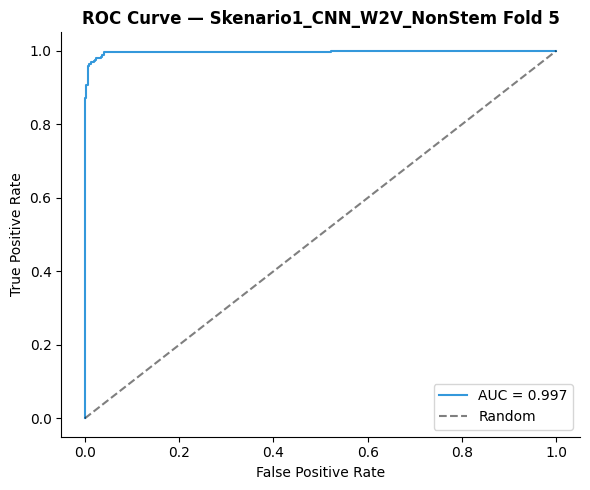


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task2_Room/Skenario1_CNN_W2V_NonStem/model.h5


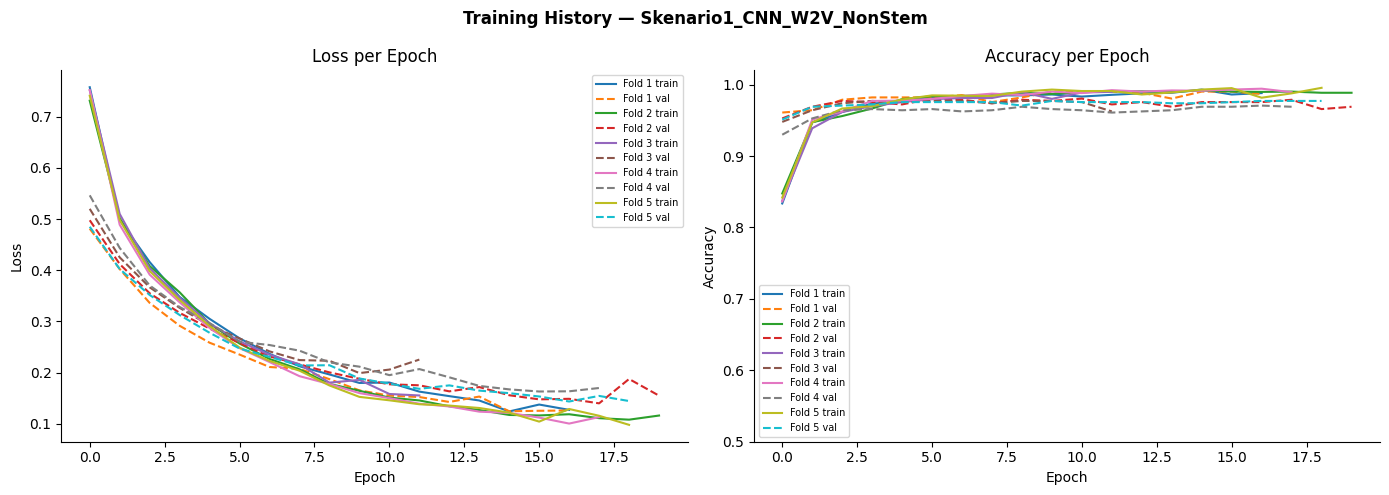


  ╔═ SELESAI: Skenario1_CNN_W2V_NonStem
  ║  avg Precision  : 0.9787 ± 0.0077
  ║  avg Recall     : 0.9781 ± 0.0075
  ║  avg F1 Macro   : 0.9784 ± 0.0076
  ║  avg Accuracy   : 0.9785 ± 0.0076
  ║  avg AUC        : 0.9965 ± 0.0024
  ║  avg RAM        : 2610.5 MB (20.1%)
  ║  avg CPU        : 13.6 %
  ║  avg Waktu      : 93.96 detik/fold
  ║  avg T/Epoch    : 5.42 detik/epoch
  ║  avg T/Step     : 0.0713 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 1 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[0])


  Training: Skenario2_CNN_W2V_Stem
  Membuat embedding matrix...
  Vocab tokenizer : 3,812 kata
  OOV             : 1,351 kata tidak ditemukan di embedding
  Shape matrix    : (3812, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1148, Neg=1304
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - accuracy: 0.8108 - auc: 0.8967 - loss: 0.7918 - val_accuracy: 0.9544 - val_auc: 0.9926 - val_loss: 0.5017
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9400 - auc: 0.9816 - loss: 0.5152 - val_accuracy: 0.9739 - val_auc: 0.9975 - val_loss: 0.3987
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9596 - auc: 0.9909 - loss: 0.4175 - val_accuracy: 0.9723 - val_auc: 0.9982 - val_loss: 0.3468
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.9690 - auc: 0.9933 - loss: 0.3631 - val_accuracy: 0.9805 - val_auc: 0.9987 - val_loss: 0.3025
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9784 - auc: 0.9956 - loss: 0.3061 - val_accuracy: 0.

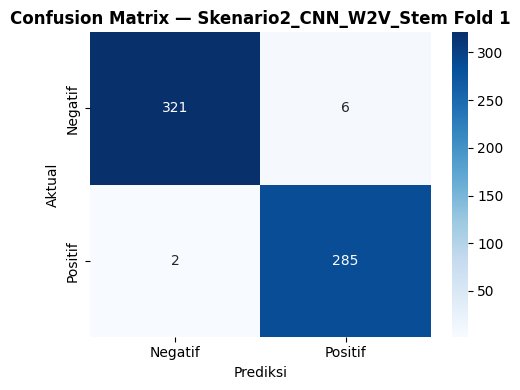

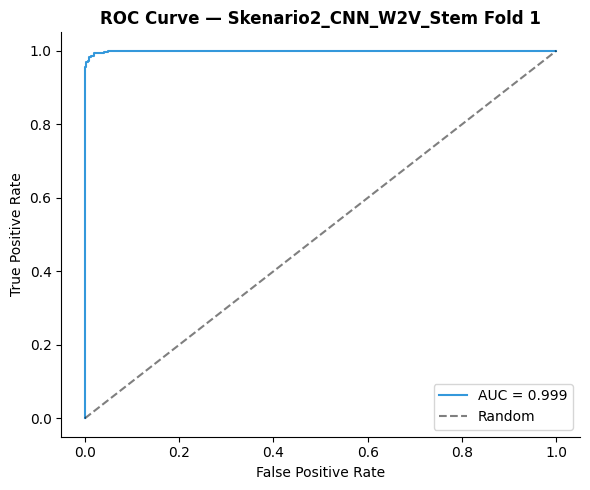


  ── Fold 2/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.8096 - auc: 0.8990 - loss: 0.7882 - val_accuracy: 0.9380 - val_auc: 0.9869 - val_loss: 0.5253
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9368 - auc: 0.9813 - loss: 0.5203 - val_accuracy: 0.9674 - val_auc: 0.9932 - val_loss: 0.4278
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.9556 - auc: 0.9903 - loss: 0.4231 - val_accuracy: 0.9723 - val_auc: 0.9945 - val_loss: 0.3747
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.9731 - auc: 0.9953 - loss: 0.3504 - val_accuracy: 0.9772 - val_auc: 0.9949 - val_loss: 0.3215
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9755 - auc: 0.9953 - loss: 0.3099 - val_accuracy: 0.9723 - val_auc: 0.9952 - val_loss: 0.2851
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.9837 - auc: 0.9968 - loss: 0.2646 - val_accuracy: 0.9788 - val_auc: 0.9953 - val_lo

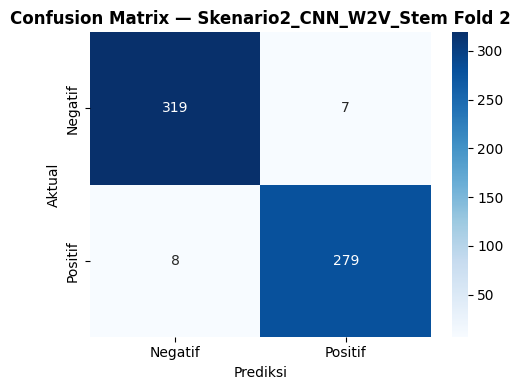

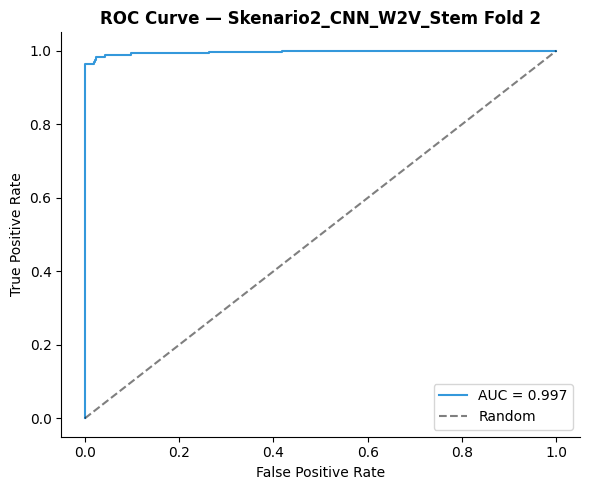


  ── Fold 3/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.7913 - auc: 0.8721 - loss: 0.8310 - val_accuracy: 0.9429 - val_auc: 0.9813 - val_loss: 0.5337
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.9331 - auc: 0.9831 - loss: 0.5055 - val_accuracy: 0.9527 - val_auc: 0.9887 - val_loss: 0.4423
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.9588 - auc: 0.9897 - loss: 0.4147 - val_accuracy: 0.9706 - val_auc: 0.9907 - val_loss: 0.3675
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9649 - auc: 0.9940 - loss: 0.3477 - val_accuracy: 0.9788 - val_auc: 0.9914 - val_loss: 0.3164
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.9731 - auc: 0.9944 - loss: 0.3046 - val_accuracy: 0.9804 - val_auc: 0.9910 - val_loss: 0.2865
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.9808 - auc: 0.9975 - loss: 0.2519 - val_accuracy: 0.9788 - val_auc: 0.9924 - val_lo

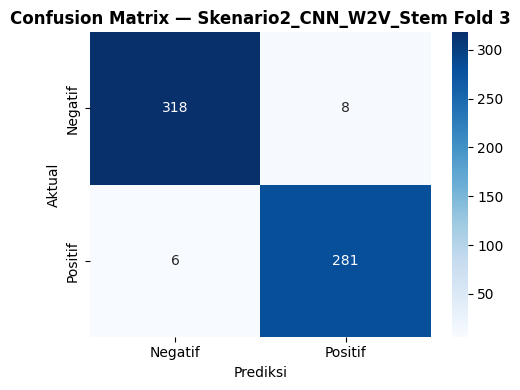

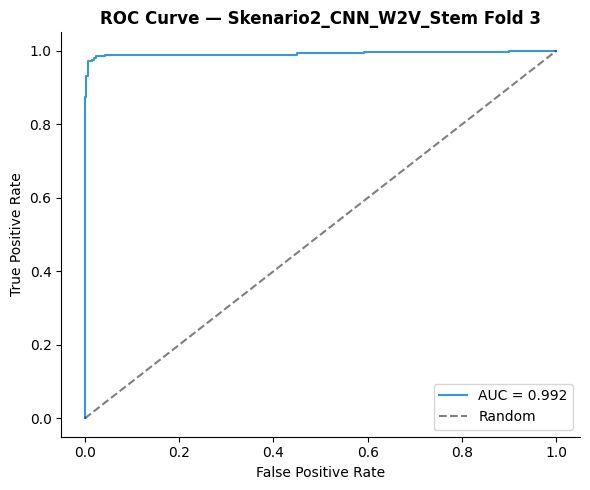


  ── Fold 4/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.8259 - auc: 0.9092 - loss: 0.7722 - val_accuracy: 0.9266 - val_auc: 0.9792 - val_loss: 0.5622
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.9421 - auc: 0.9850 - loss: 0.4957 - val_accuracy: 0.9527 - val_auc: 0.9906 - val_loss: 0.4393
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.9633 - auc: 0.9913 - loss: 0.4120 - val_accuracy: 0.9560 - val_auc: 0.9934 - val_loss: 0.3984
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.9743 - auc: 0.9939 - loss: 0.3451 - val_accuracy: 0.9592 - val_auc: 0.9953 - val_loss: 0.3399
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.9817 - auc: 0.9963 - loss: 0.2946 - val_accuracy: 0.9608 - val_auc: 0.9957 - val_loss: 0.3185
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.9845 - auc: 0.9974 - loss: 0.2547 - val_accuracy: 0.9608 - val_auc: 0.9959 - val_lo

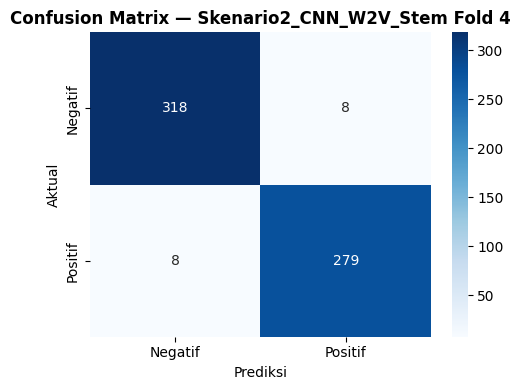

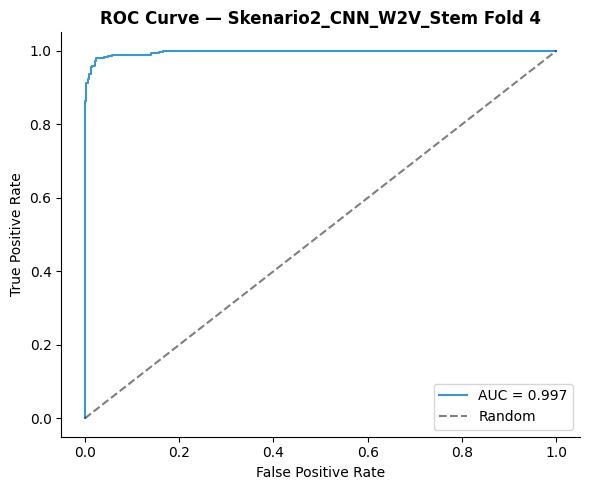


  ── Fold 5/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - accuracy: 0.8251 - auc: 0.9104 - loss: 0.7639 - val_accuracy: 0.9511 - val_auc: 0.9902 - val_loss: 0.5060
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 0.9368 - auc: 0.9811 - loss: 0.5153 - val_accuracy: 0.9641 - val_auc: 0.9951 - val_loss: 0.4157
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9637 - auc: 0.9910 - loss: 0.4143 - val_accuracy: 0.9772 - val_auc: 0.9965 - val_loss: 0.3608
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.9727 - auc: 0.9942 - loss: 0.3545 - val_accuracy: 0.9755 - val_auc: 0.9967 - val_loss: 0.3231
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.9817 - auc: 0.9959 - loss: 0.3003 - val_accuracy: 0.9788 - val_auc: 0.9971 - val_loss: 0.2868
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.9841 - auc: 0.9979 - loss: 0.2589 - val_accuracy: 0.9788 - val_auc: 0.9959 - val_lo

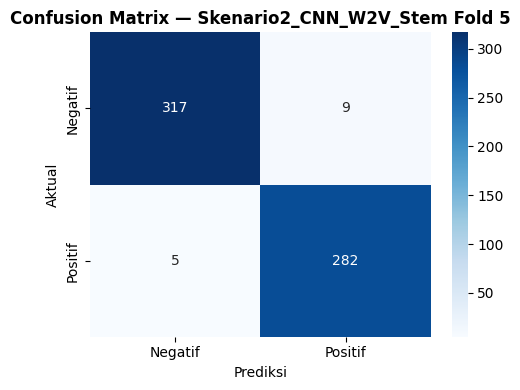

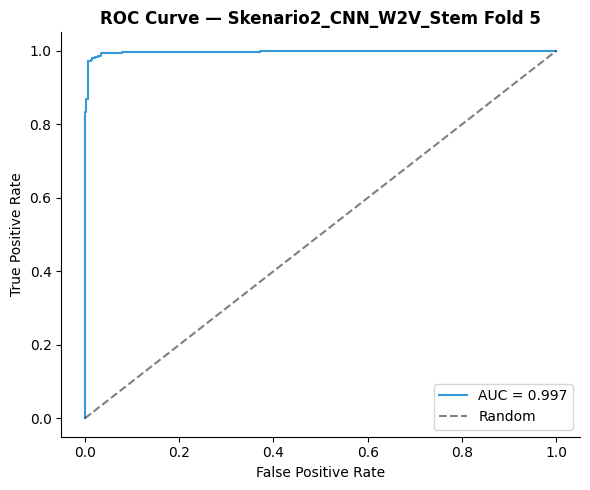


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task2_Room/Skenario2_CNN_W2V_Stem/model.h5


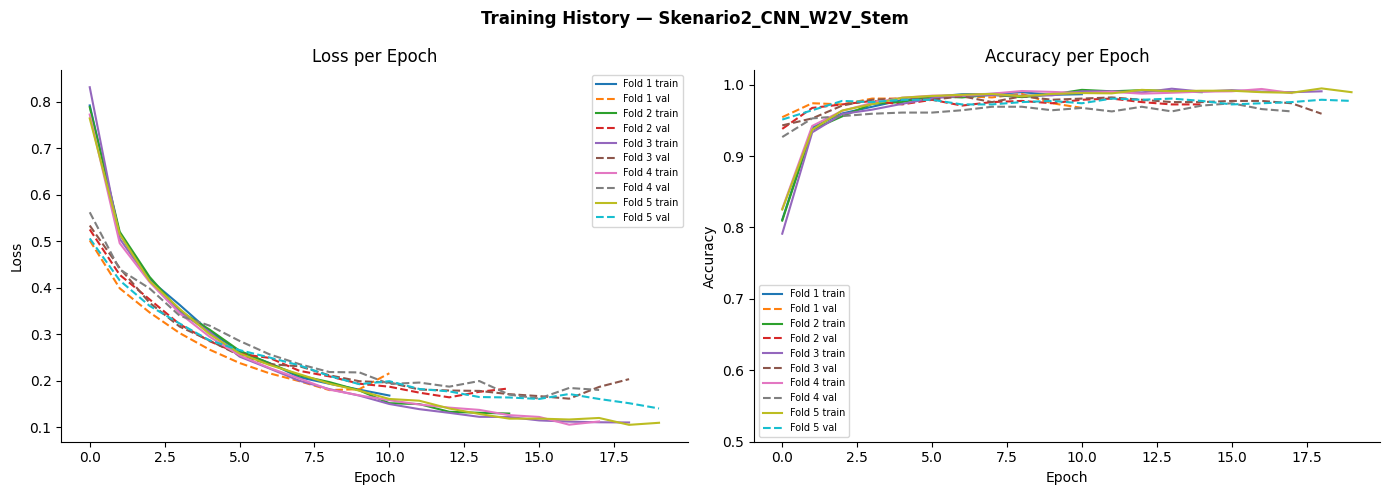


  ╔═ SELESAI: Skenario2_CNN_W2V_Stem
  ║  avg Precision  : 0.9779 ± 0.0050
  ║  avg Recall     : 0.9782 ± 0.0053
  ║  avg F1 Macro   : 0.9781 ± 0.0051
  ║  avg Accuracy   : 0.9781 ± 0.0051
  ║  avg AUC        : 0.9965 ± 0.0025
  ║  avg RAM        : 2695.6 MB (20.8%)
  ║  avg CPU        : 34.3 %
  ║  avg Waktu      : 95.47 detik/fold
  ║  avg T/Epoch    : 5.64 detik/epoch
  ║  avg T/Step     : 0.0743 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 2 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[1])


  Training: Skenario3_CNN_FT_NonStem
  Membuat embedding matrix...
  Vocab tokenizer : 5,546 kata
  OOV             : 0 kata tidak ditemukan di embedding
  Shape matrix    : (5546, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1148, Neg=1304
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.8030 - auc: 0.8901 - loss: 0.8002 - val_accuracy: 0.9577 - val_auc: 0.9933 - val_loss: 0.4922
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9392 - auc: 0.9823 - loss: 0.5083 - val_accuracy: 0.9772 - val_auc: 0.9969 - val_loss: 0.3993
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.9555 - auc: 0.9899 - loss: 0.4209 - val_accuracy: 0.9788 - val_auc: 0.9983 - val_loss: 0.3420
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.9657 - auc: 0.9931 - loss: 0.3623 - val_accuracy: 0.9788 - val_auc: 0.9989 - val_loss: 0.3065
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9719 - auc: 0.9937 - loss: 0.3187 - val_accuracy: 0.982

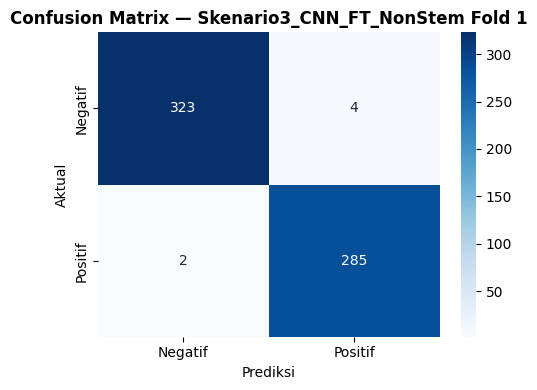

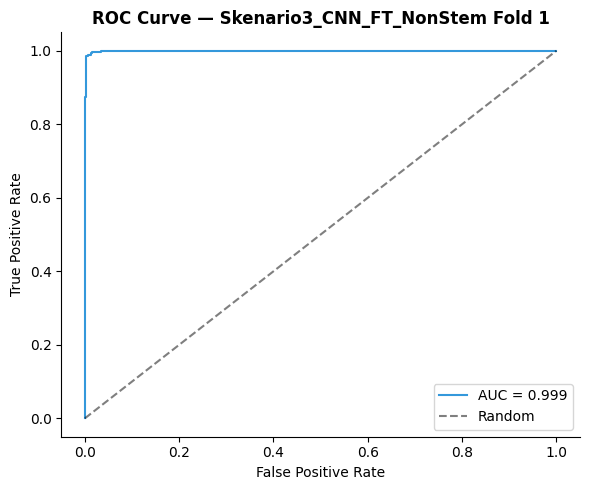


  ── Fold 2/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.8096 - auc: 0.9030 - loss: 0.7749 - val_accuracy: 0.9494 - val_auc: 0.9887 - val_loss: 0.5051
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.9401 - auc: 0.9814 - loss: 0.5089 - val_accuracy: 0.9625 - val_auc: 0.9927 - val_loss: 0.4291
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.9600 - auc: 0.9886 - loss: 0.4168 - val_accuracy: 0.9739 - val_auc: 0.9939 - val_loss: 0.3586
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.9706 - auc: 0.9936 - loss: 0.3476 - val_accuracy: 0.9723 - val_auc: 0.9948 - val_loss: 0.3162
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9764 - auc: 0.9950 - loss: 0.2989 - val_accuracy: 0.9739 - val_auc: 0.9948 - val_loss: 0.2816
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9837 - auc: 0.9957 - loss: 0.2578 - val_accuracy: 0.9723 - val_auc: 0.9951 - val_l

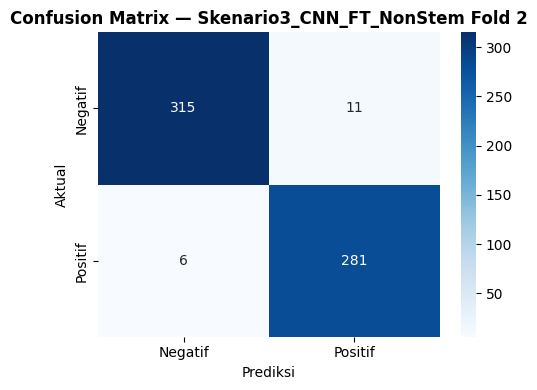

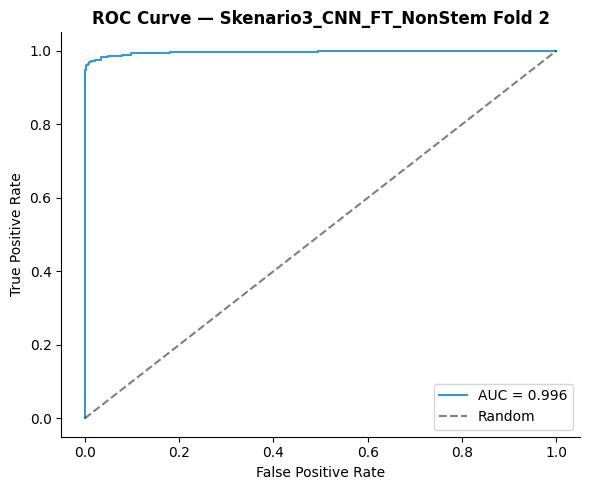


  ── Fold 3/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.8210 - auc: 0.9057 - loss: 0.7794 - val_accuracy: 0.9494 - val_auc: 0.9836 - val_loss: 0.5264
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.9466 - auc: 0.9861 - loss: 0.4990 - val_accuracy: 0.9641 - val_auc: 0.9892 - val_loss: 0.4386
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.9629 - auc: 0.9919 - loss: 0.4148 - val_accuracy: 0.9641 - val_auc: 0.9908 - val_loss: 0.3842
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.9678 - auc: 0.9935 - loss: 0.3660 - val_accuracy: 0.9641 - val_auc: 0.9913 - val_loss: 0.3526
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9764 - auc: 0.9961 - loss: 0.3112 - val_accuracy: 0.9755 - val_auc: 0.9924 - val_loss: 0.3036
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9796 - auc: 0.9972 - loss: 0.2743 - val_accuracy: 0.9739 - val_auc: 0.9922 - val_lo

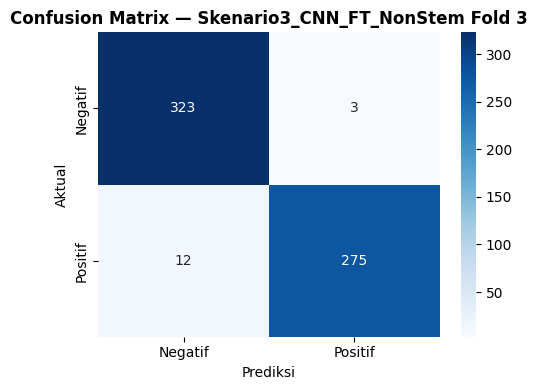

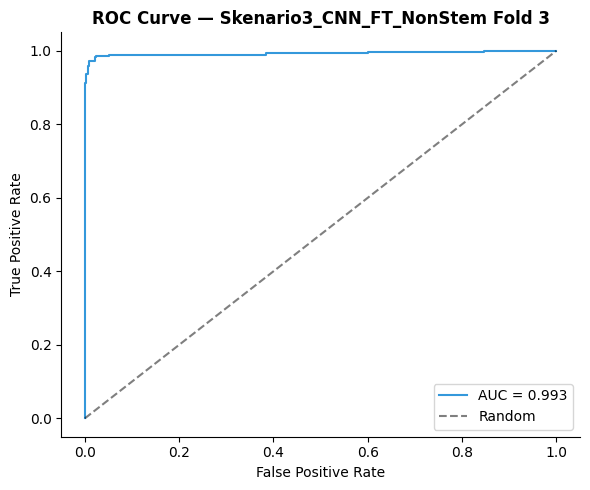


  ── Fold 4/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.8276 - auc: 0.9106 - loss: 0.7625 - val_accuracy: 0.9250 - val_auc: 0.9813 - val_loss: 0.5822
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.9474 - auc: 0.9847 - loss: 0.4910 - val_accuracy: 0.9543 - val_auc: 0.9899 - val_loss: 0.4421
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.9596 - auc: 0.9905 - loss: 0.4099 - val_accuracy: 0.9706 - val_auc: 0.9932 - val_loss: 0.3791
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.9731 - auc: 0.9933 - loss: 0.3452 - val_accuracy: 0.9608 - val_auc: 0.9946 - val_loss: 0.3439
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.9755 - auc: 0.9952 - loss: 0.2972 - val_accuracy: 0.9690 - val_auc: 0.9948 - val_loss: 0.3012
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.9796 - auc: 0.9961 - loss: 0.2631 - val_accuracy: 0.9592 - val_auc: 0.9950 - val_l

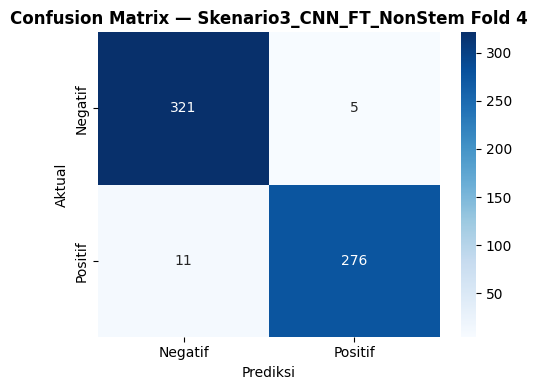

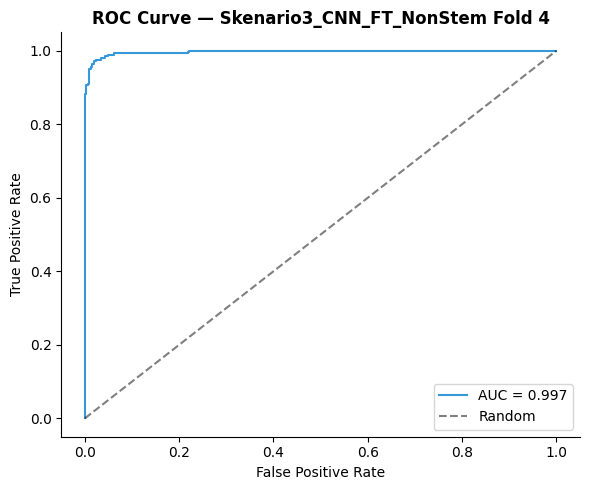


  ── Fold 5/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - accuracy: 0.8166 - auc: 0.9060 - loss: 0.7747 - val_accuracy: 0.9429 - val_auc: 0.9919 - val_loss: 0.5111
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.9401 - auc: 0.9818 - loss: 0.5096 - val_accuracy: 0.9674 - val_auc: 0.9952 - val_loss: 0.4129
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.9605 - auc: 0.9918 - loss: 0.4075 - val_accuracy: 0.9625 - val_auc: 0.9958 - val_loss: 0.3725
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.9747 - auc: 0.9939 - loss: 0.3442 - val_accuracy: 0.9690 - val_auc: 0.9965 - val_loss: 0.3253
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9776 - auc: 0.9950 - loss: 0.3001 - val_accuracy: 0.9723 - val_auc: 0.9954 - val_loss: 0.2892
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9800 - auc: 0.9955 - loss: 0.2686 - val_accuracy: 0.9739 - val_auc: 0.9954 - val_lo

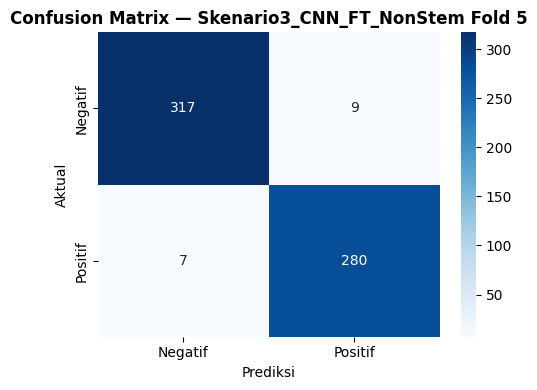

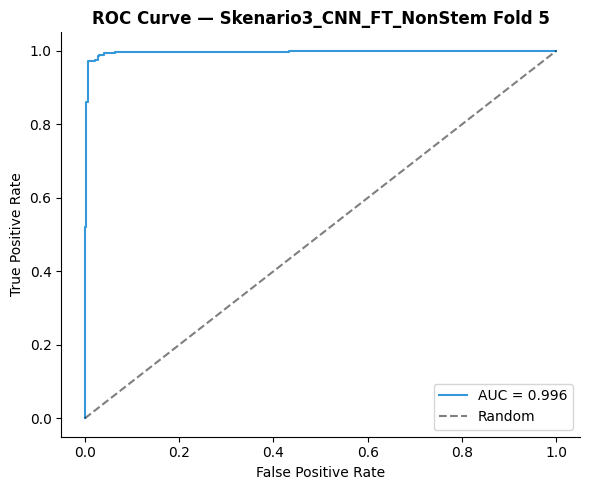


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task2_Room/Skenario3_CNN_FT_NonStem/model.h5


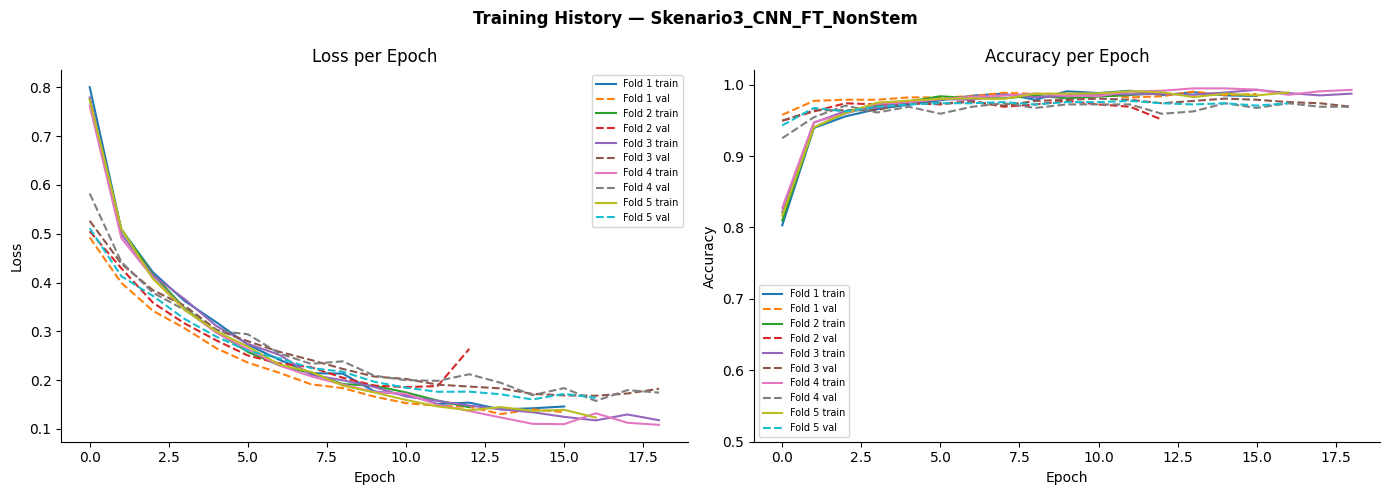


  ╔═ SELESAI: Skenario3_CNN_FT_NonStem
  ║  avg Precision  : 0.9773 ± 0.0073
  ║  avg Recall     : 0.9769 ± 0.0076
  ║  avg F1 Macro   : 0.9771 ± 0.0074
  ║  avg Accuracy   : 0.9772 ± 0.0074
  ║  avg AUC        : 0.9963 ± 0.0024
  ║  avg RAM        : 2833.2 MB (21.8%)
  ║  avg CPU        : 13.5 %
  ║  avg Waktu      : 96.57 detik/fold
  ║  avg T/Epoch    : 5.74 detik/epoch
  ║  avg T/Step     : 0.0755 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 3 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[2])


  Training: Skenario4_CNN_FT_Stem
  Membuat embedding matrix...
  Vocab tokenizer : 3,812 kata
  OOV             : 0 kata tidak ditemukan di embedding
  Shape matrix    : (3812, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1148, Neg=1304
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.7834 - auc: 0.8747 - loss: 0.8232 - val_accuracy: 0.9528 - val_auc: 0.9924 - val_loss: 0.5034
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.9392 - auc: 0.9818 - loss: 0.5105 - val_accuracy: 0.9658 - val_auc: 0.9969 - val_loss: 0.4054
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.9584 - auc: 0.9896 - loss: 0.4192 - val_accuracy: 0.9756 - val_auc: 0.9979 - val_loss: 0.3474
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9678 - auc: 0.9913 - loss: 0.3686 - val_accuracy: 0.9723 - val_auc: 0.9985 - val_loss: 0.3169
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.9780 - auc: 0.9951 - loss: 0.3095 - val_accuracy: 0.9707 -

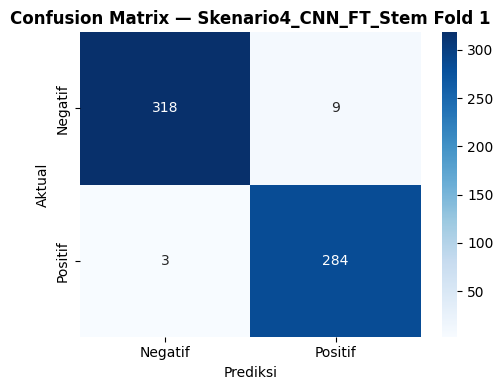

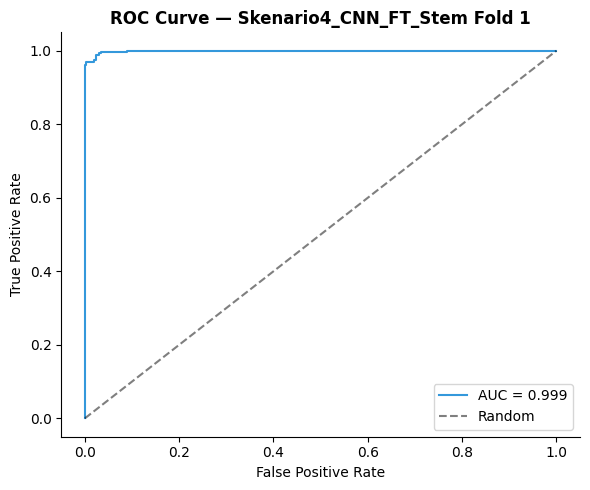


  ── Fold 2/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.7970 - auc: 0.8910 - loss: 0.7972 - val_accuracy: 0.9331 - val_auc: 0.9880 - val_loss: 0.5386
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9344 - auc: 0.9797 - loss: 0.5258 - val_accuracy: 0.9674 - val_auc: 0.9933 - val_loss: 0.4210
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.9552 - auc: 0.9896 - loss: 0.4298 - val_accuracy: 0.9706 - val_auc: 0.9948 - val_loss: 0.3702
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.9674 - auc: 0.9929 - loss: 0.3640 - val_accuracy: 0.9723 - val_auc: 0.9949 - val_loss: 0.3413
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.9723 - auc: 0.9947 - loss: 0.3207 - val_accuracy: 0.9755 - val_auc: 0.9958 - val_loss: 0.2984
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.9812 - auc: 0.9966 - loss: 0.2702 - val_accuracy: 0.9755 - val_auc: 0.9951 - val_l

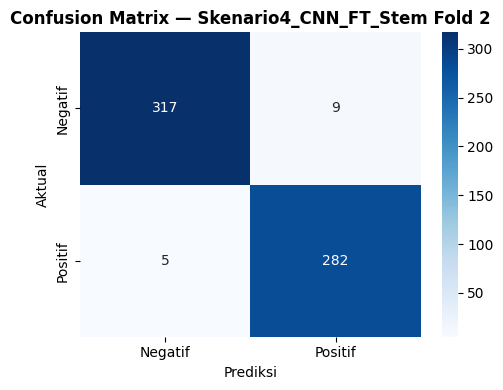

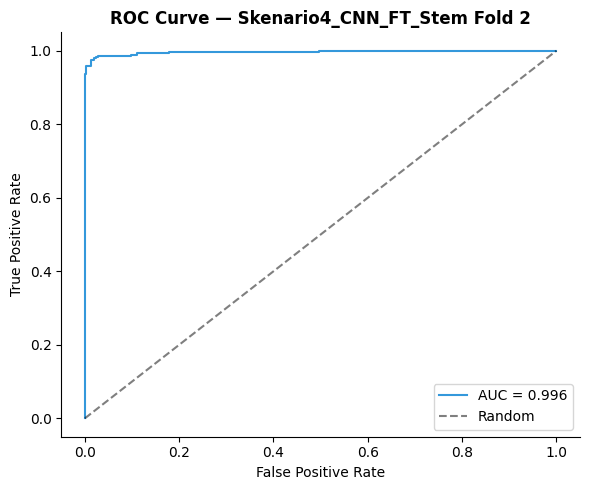


  ── Fold 3/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - accuracy: 0.8064 - auc: 0.8985 - loss: 0.7870 - val_accuracy: 0.9413 - val_auc: 0.9813 - val_loss: 0.5406
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9331 - auc: 0.9823 - loss: 0.5098 - val_accuracy: 0.9674 - val_auc: 0.9881 - val_loss: 0.4359
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.9564 - auc: 0.9899 - loss: 0.4172 - val_accuracy: 0.9674 - val_auc: 0.9897 - val_loss: 0.3741
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.9649 - auc: 0.9943 - loss: 0.3522 - val_accuracy: 0.9706 - val_auc: 0.9909 - val_loss: 0.3296
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.9747 - auc: 0.9966 - loss: 0.3000 - val_accuracy: 0.9739 - val_auc: 0.9918 - val_loss: 0.3031
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9796 - auc: 0.9982 - loss: 0.2551 - val_accuracy: 0.9772 - val_auc: 0.9924 - val_lo

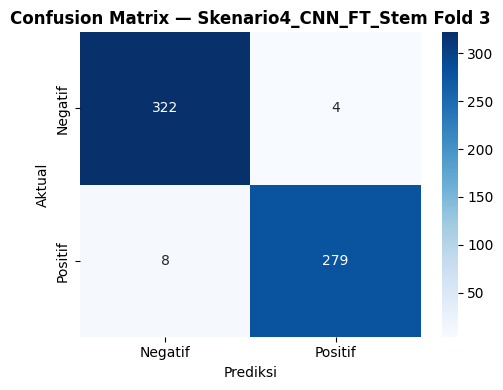

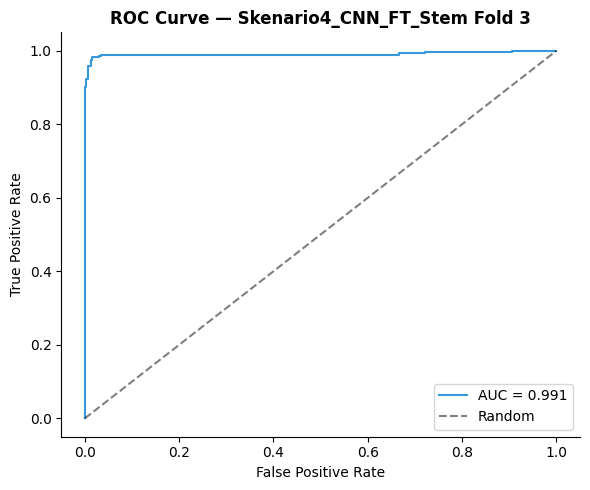


  ── Fold 4/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.8129 - auc: 0.8937 - loss: 0.7933 - val_accuracy: 0.9282 - val_auc: 0.9804 - val_loss: 0.5633
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.9380 - auc: 0.9822 - loss: 0.5010 - val_accuracy: 0.9511 - val_auc: 0.9906 - val_loss: 0.4339
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.9641 - auc: 0.9909 - loss: 0.3996 - val_accuracy: 0.9560 - val_auc: 0.9943 - val_loss: 0.3739
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9662 - auc: 0.9943 - loss: 0.3418 - val_accuracy: 0.9576 - val_auc: 0.9960 - val_loss: 0.3371
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9788 - auc: 0.9962 - loss: 0.2899 - val_accuracy: 0.9608 - val_auc: 0.9960 - val_loss: 0.2935
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.9784 - auc: 0.9956 - loss: 0.2602 - val_accuracy: 0.9625 - val_auc: 0.9970 - val_lo

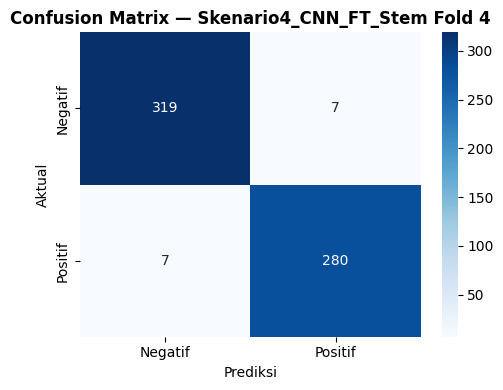

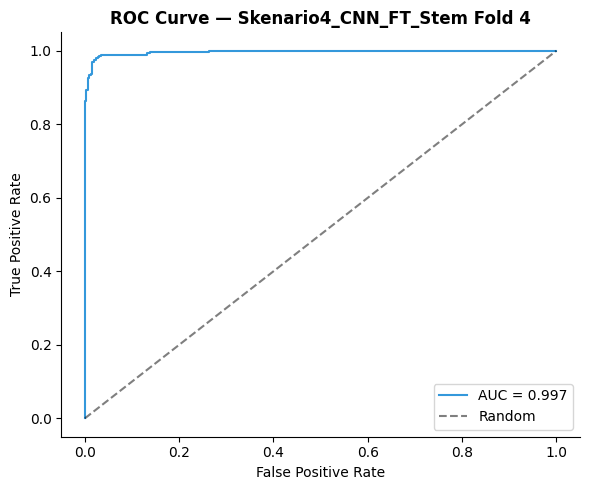


  ── Fold 5/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.8035 - auc: 0.8880 - loss: 0.8042 - val_accuracy: 0.9396 - val_auc: 0.9876 - val_loss: 0.5152
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.9364 - auc: 0.9773 - loss: 0.5178 - val_accuracy: 0.9641 - val_auc: 0.9940 - val_loss: 0.4090
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.9556 - auc: 0.9882 - loss: 0.4186 - val_accuracy: 0.9723 - val_auc: 0.9963 - val_loss: 0.3467
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9694 - auc: 0.9935 - loss: 0.3450 - val_accuracy: 0.9755 - val_auc: 0.9967 - val_loss: 0.3035
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.9764 - auc: 0.9958 - loss: 0.2929 - val_accuracy: 0.9755 - val_auc: 0.9971 - val_loss: 0.2721
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.9788 - auc: 0.9951 - loss: 0.2638 - val_accuracy: 0.9755 - val_auc: 0.9972 - val_l

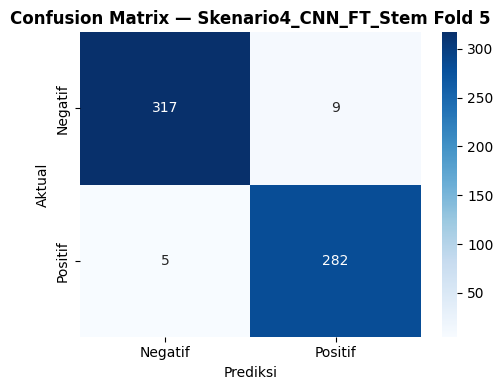

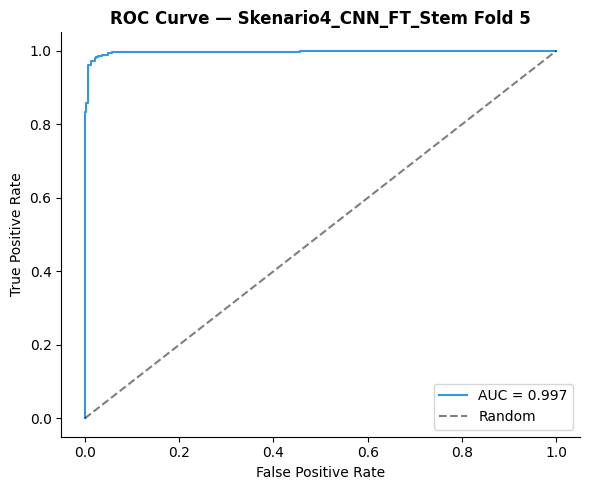


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task2_Room/Skenario4_CNN_FT_Stem/model.h5


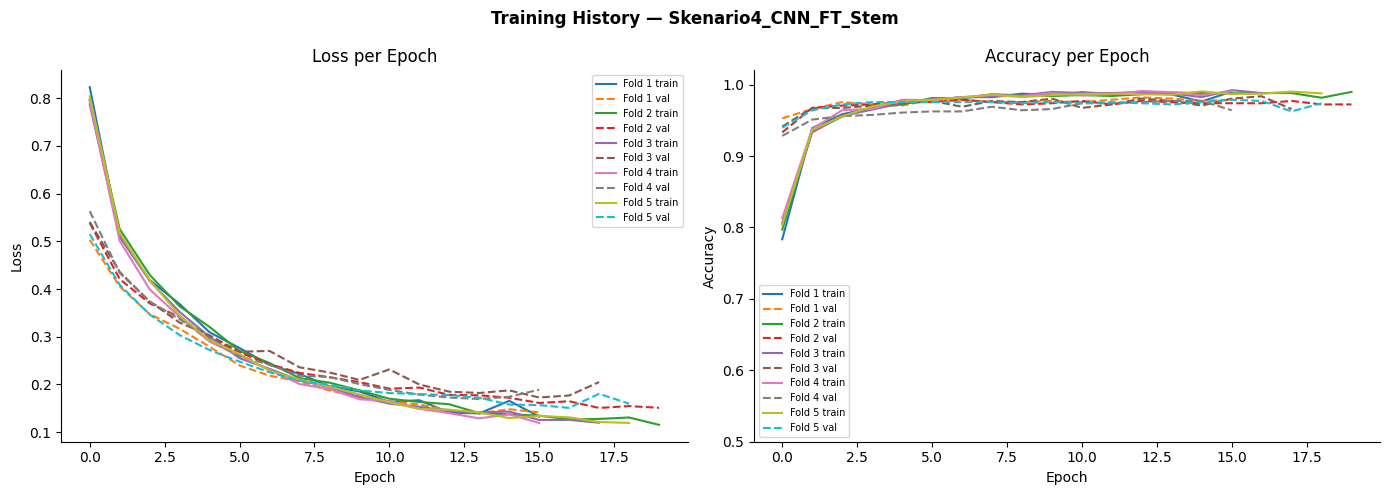


  ╔═ SELESAI: Skenario4_CNN_FT_Stem
  ║  avg Precision  : 0.9783 ± 0.0020
  ║  avg Recall     : 0.9786 ± 0.0018
  ║  avg F1 Macro   : 0.9784 ± 0.0018
  ║  avg Accuracy   : 0.9785 ± 0.0018
  ║  avg AUC        : 0.9960 ± 0.0029
  ║  avg RAM        : 2922.7 MB (22.5%)
  ║  avg CPU        : 23.4 %
  ║  avg Waktu      : 101.63 detik/fold
  ║  avg T/Epoch    : 5.63 detik/epoch
  ║  avg T/Step     : 0.0741 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 4 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[3])


  Training: Skenario5_BiLSTM_W2V_NonStem
  Membuat embedding matrix...
  Vocab tokenizer : 5,546 kata
  OOV             : 2,156 kata tidak ditemukan di embedding
  Shape matrix    : (5546, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1148, Neg=1304
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 29s 278ms/step - accuracy: 0.8165 - auc: 0.9002 - loss: 0.4847 - val_accuracy: 0.9365 - val_auc: 0.9864 - val_loss: 0.2154
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 18s 236ms/step - accuracy: 0.9229 - auc: 0.9659 - loss: 0.2732 - val_accuracy: 0.9511 - val_auc: 0.9912 - val_loss: 0.1695
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 18s 235ms/step - accuracy: 0.9250 - auc: 0.9741 - loss: 0.2370 - val_accuracy: 0.9544 - val_auc: 0.9929 - val_loss: 0.1457
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 18s 235ms/step - accuracy: 0.9384 - auc: 0.9766 - loss: 0.2157 - val_accuracy: 0.9723 - val_auc: 0.9942 - val_loss: 0.1273
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 23s 270ms/step - accuracy: 0.9413 - auc: 0.9835 - loss: 0.1845 - v

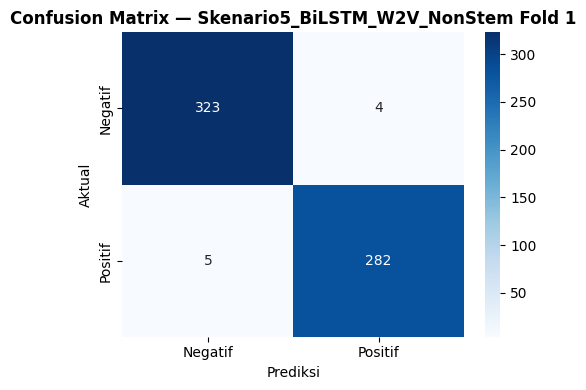

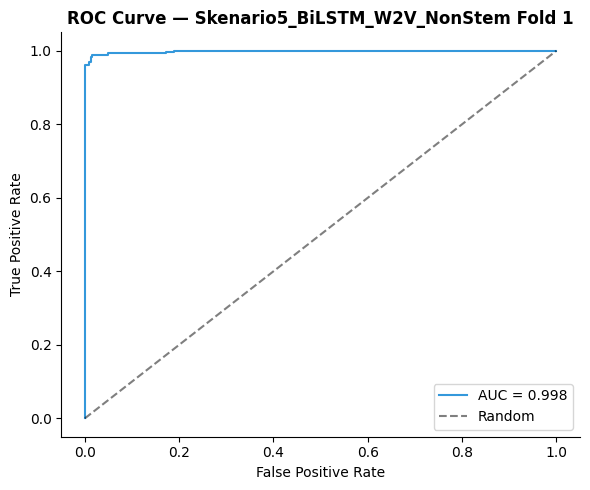


  ── Fold 2/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 29s 256ms/step - accuracy: 0.8166 - auc: 0.8983 - loss: 0.4913 - val_accuracy: 0.9168 - val_auc: 0.9774 - val_loss: 0.2745
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 242ms/step - accuracy: 0.9156 - auc: 0.9616 - loss: 0.2845 - val_accuracy: 0.9331 - val_auc: 0.9832 - val_loss: 0.2085
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 259ms/step - accuracy: 0.9344 - auc: 0.9725 - loss: 0.2278 - val_accuracy: 0.9429 - val_auc: 0.9823 - val_loss: 0.1940
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 240ms/step - accuracy: 0.9409 - auc: 0.9769 - loss: 0.2079 - val_accuracy: 0.9543 - val_auc: 0.9885 - val_loss: 0.1580
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 18s 234ms/step - accuracy: 0.9499 - auc: 0.9832 - loss: 0.1760 - val_accuracy: 0.9625 - val_auc: 0.9913 - val_loss: 0.1323
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 18s 235ms/step - accuracy: 0.9609 - auc: 0.9885 - loss: 0.1473 - val_accuracy: 0.9657 - val_auc: 0.9

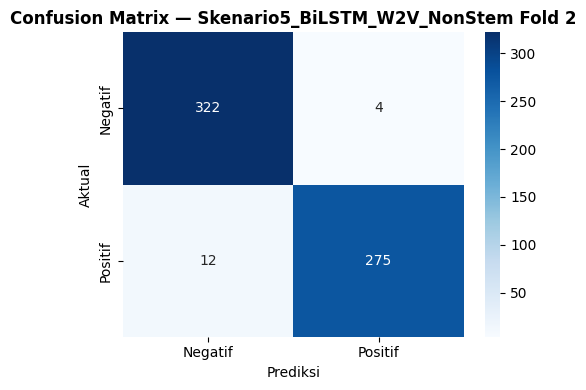

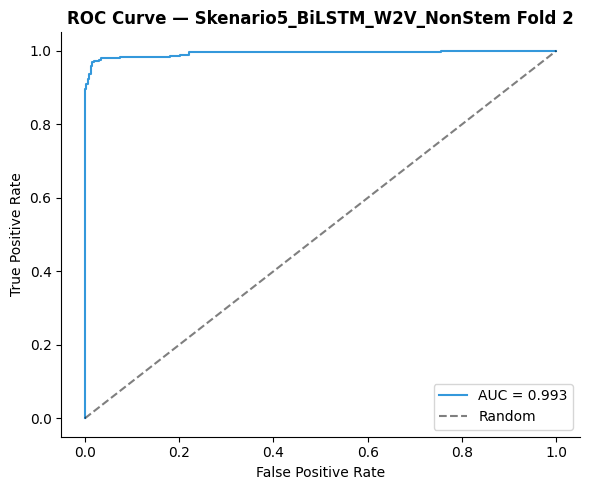


  ── Fold 3/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 29s 278ms/step - accuracy: 0.7941 - auc: 0.8838 - loss: 0.5077 - val_accuracy: 0.9266 - val_auc: 0.9739 - val_loss: 0.2602
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 38s 245ms/step - accuracy: 0.9172 - auc: 0.9662 - loss: 0.2745 - val_accuracy: 0.9429 - val_auc: 0.9791 - val_loss: 0.2162
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 21s 253ms/step - accuracy: 0.9352 - auc: 0.9779 - loss: 0.2204 - val_accuracy: 0.9462 - val_auc: 0.9853 - val_loss: 0.1917
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 246ms/step - accuracy: 0.9368 - auc: 0.9809 - loss: 0.2003 - val_accuracy: 0.9543 - val_auc: 0.9883 - val_loss: 0.1578
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 245ms/step - accuracy: 0.9519 - auc: 0.9853 - loss: 0.1750 - val_accuracy: 0.9608 - val_auc: 0.9898 - val_loss: 0.1418
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 22s 278ms/step - accuracy: 0.9568 - auc: 0.9881 - loss: 0.1509 - val_accuracy: 0.9641 - val_auc: 0.9

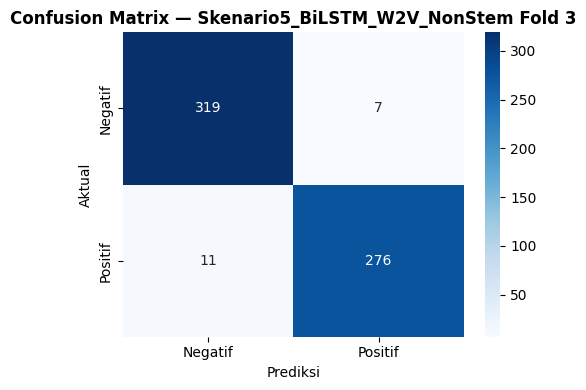

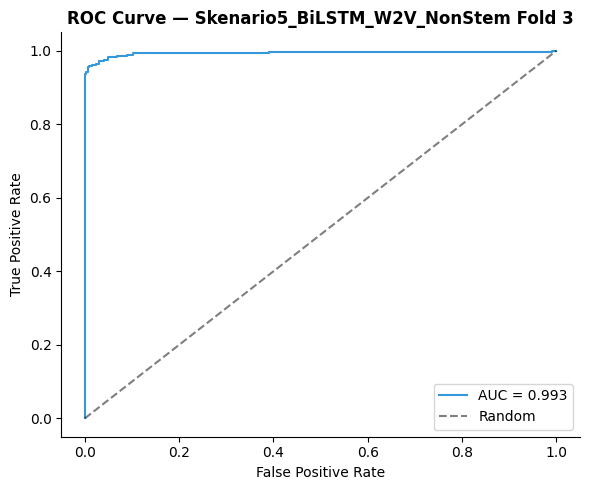


  ── Fold 4/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 29s 261ms/step - accuracy: 0.7835 - auc: 0.8770 - loss: 0.5221 - val_accuracy: 0.9233 - val_auc: 0.9694 - val_loss: 0.2812
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 243ms/step - accuracy: 0.9132 - auc: 0.9634 - loss: 0.2787 - val_accuracy: 0.9266 - val_auc: 0.9765 - val_loss: 0.2302
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 21s 247ms/step - accuracy: 0.9360 - auc: 0.9748 - loss: 0.2269 - val_accuracy: 0.9380 - val_auc: 0.9829 - val_loss: 0.1977
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 244ms/step - accuracy: 0.9409 - auc: 0.9804 - loss: 0.2022 - val_accuracy: 0.9511 - val_auc: 0.9854 - val_loss: 0.1736
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 237ms/step - accuracy: 0.9425 - auc: 0.9805 - loss: 0.1922 - val_accuracy: 0.9527 - val_auc: 0.9871 - val_loss: 0.1717
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 21s 246ms/step - accuracy: 0.9523 - auc: 0.9863 - loss: 0.1616 - val_accuracy: 0.9543 - val_auc: 0.9

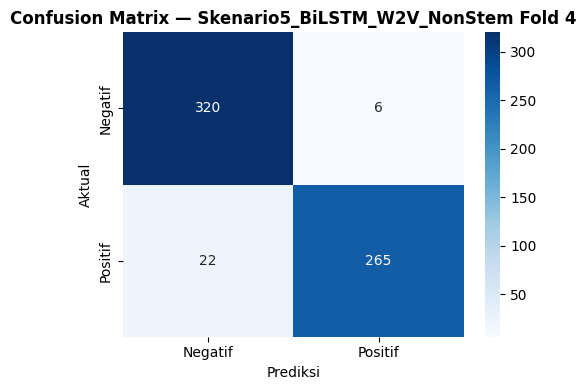

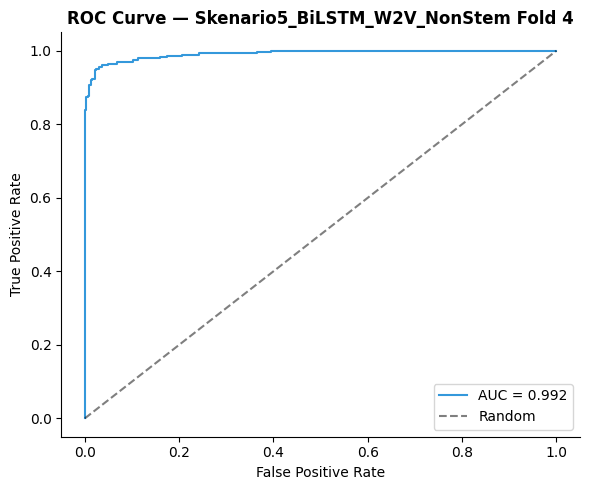


  ── Fold 5/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 31s 284ms/step - accuracy: 0.7970 - auc: 0.8830 - loss: 0.5096 - val_accuracy: 0.9201 - val_auc: 0.9795 - val_loss: 0.2530
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 248ms/step - accuracy: 0.9160 - auc: 0.9634 - loss: 0.2819 - val_accuracy: 0.9429 - val_auc: 0.9872 - val_loss: 0.1915
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 18s 240ms/step - accuracy: 0.9287 - auc: 0.9733 - loss: 0.2357 - val_accuracy: 0.9494 - val_auc: 0.9906 - val_loss: 0.1650
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 241ms/step - accuracy: 0.9442 - auc: 0.9783 - loss: 0.2045 - val_accuracy: 0.9592 - val_auc: 0.9927 - val_loss: 0.1441
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 22s 253ms/step - accuracy: 0.9450 - auc: 0.9804 - loss: 0.1940 - val_accuracy: 0.9543 - val_auc: 0.9936 - val_loss: 0.1363
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 18s 239ms/step - accuracy: 0.9576 - auc: 0.9842 - loss: 0.1681 - val_accuracy: 0.9657 - val_auc: 0.9

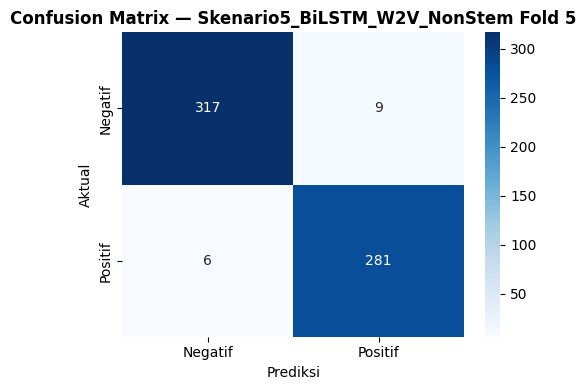

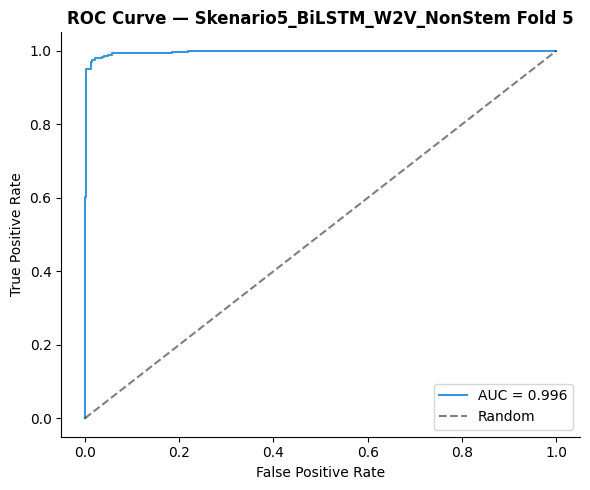


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task2_Room/Skenario5_BiLSTM_W2V_NonStem/model.h5


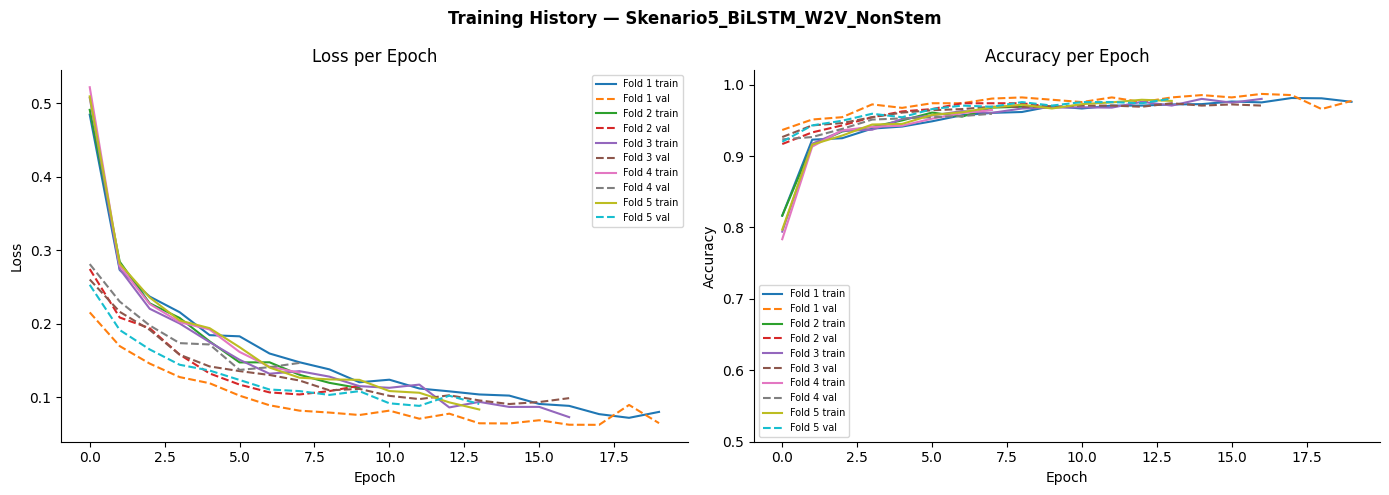


  ╔═ SELESAI: Skenario5_BiLSTM_W2V_NonStem
  ║  avg Precision  : 0.9726 ± 0.0104
  ║  avg Recall     : 0.9713 ± 0.0119
  ║  avg F1 Macro   : 0.9718 ± 0.0114
  ║  avg Accuracy   : 0.9719 ± 0.0113
  ║  avg AUC        : 0.9946 ± 0.0027
  ║  avg RAM        : 3197.0 MB (24.6%)
  ║  avg CPU        : 27.3 %
  ║  avg Waktu      : 284.91 detik/fold
  ║  avg T/Epoch    : 20.56 detik/epoch
  ║  avg T/Step     : 0.2705 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 5 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[4])


  Training: Skenario6_BiLSTM_W2V_Stem
  Membuat embedding matrix...
  Vocab tokenizer : 3,812 kata
  OOV             : 1,351 kata tidak ditemukan di embedding
  Shape matrix    : (3812, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1148, Neg=1304
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 29s 265ms/step - accuracy: 0.7834 - auc: 0.8786 - loss: 0.5167 - val_accuracy: 0.9446 - val_auc: 0.9873 - val_loss: 0.2284
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 244ms/step - accuracy: 0.9152 - auc: 0.9642 - loss: 0.2829 - val_accuracy: 0.9577 - val_auc: 0.9916 - val_loss: 0.1709
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 236ms/step - accuracy: 0.9229 - auc: 0.9659 - loss: 0.2619 - val_accuracy: 0.9642 - val_auc: 0.9932 - val_loss: 0.1517
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 22s 249ms/step - accuracy: 0.9339 - auc: 0.9777 - loss: 0.2164 - val_accuracy: 0.9609 - val_auc: 0.9937 - val_loss: 0.1376
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 238ms/step - accuracy: 0.9409 - auc: 0.9782 - loss: 0.2048 - val_

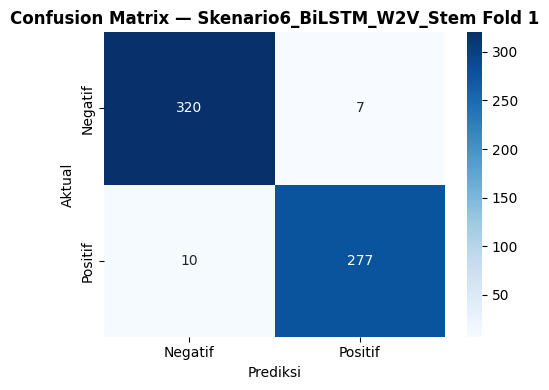

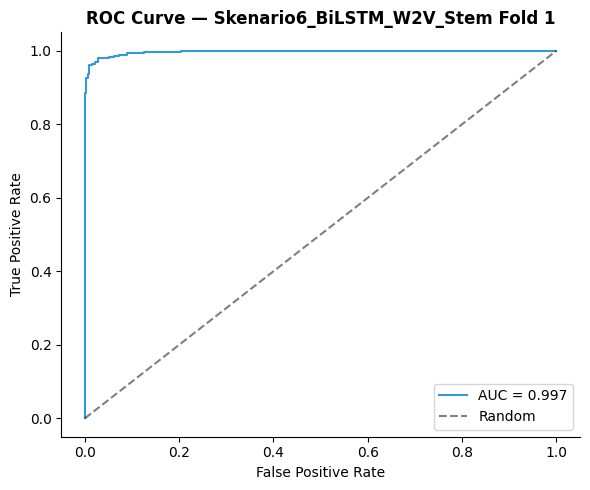


  ── Fold 2/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 28s 248ms/step - accuracy: 0.8007 - auc: 0.8910 - loss: 0.5030 - val_accuracy: 0.9070 - val_auc: 0.9749 - val_loss: 0.2724
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 243ms/step - accuracy: 0.9087 - auc: 0.9574 - loss: 0.3050 - val_accuracy: 0.9315 - val_auc: 0.9820 - val_loss: 0.2208
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 18s 236ms/step - accuracy: 0.9303 - auc: 0.9715 - loss: 0.2411 - val_accuracy: 0.9445 - val_auc: 0.9857 - val_loss: 0.1878
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 261ms/step - accuracy: 0.9360 - auc: 0.9776 - loss: 0.2138 - val_accuracy: 0.9527 - val_auc: 0.9901 - val_loss: 0.1514
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 245ms/step - accuracy: 0.9478 - auc: 0.9808 - loss: 0.1885 - val_accuracy: 0.9576 - val_auc: 0.9917 - val_loss: 0.1352
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 18s 236ms/step - accuracy: 0.9482 - auc: 0.9871 - loss: 0.1673 - val_accuracy: 0.9657 - val_auc: 0.9

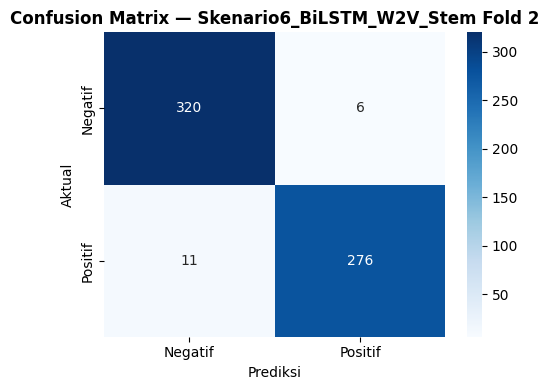

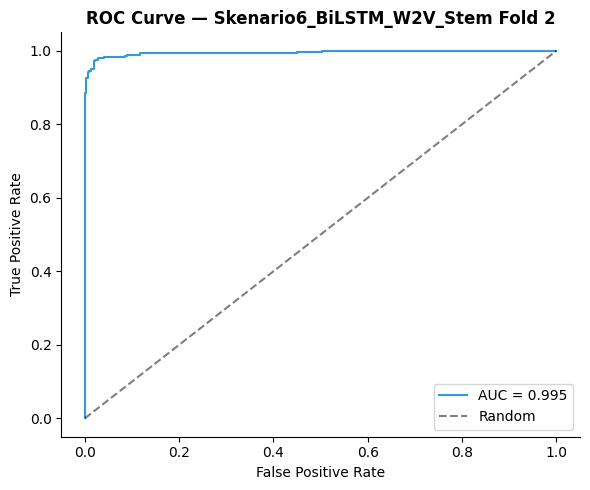


  ── Fold 3/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 31s 299ms/step - accuracy: 0.8064 - auc: 0.8901 - loss: 0.4983 - val_accuracy: 0.9250 - val_auc: 0.9729 - val_loss: 0.2592
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 18s 239ms/step - accuracy: 0.9164 - auc: 0.9626 - loss: 0.2840 - val_accuracy: 0.9413 - val_auc: 0.9798 - val_loss: 0.2152
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 18s 238ms/step - accuracy: 0.9230 - auc: 0.9698 - loss: 0.2491 - val_accuracy: 0.9494 - val_auc: 0.9836 - val_loss: 0.1909
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 22s 260ms/step - accuracy: 0.9327 - auc: 0.9740 - loss: 0.2240 - val_accuracy: 0.9560 - val_auc: 0.9870 - val_loss: 0.1634
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 246ms/step - accuracy: 0.9389 - auc: 0.9779 - loss: 0.2076 - val_accuracy: 0.9592 - val_auc: 0.9879 - val_loss: 0.1487
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 246ms/step - accuracy: 0.9450 - auc: 0.9839 - loss: 0.1792 - val_accuracy: 0.9674 - val_auc: 0.9

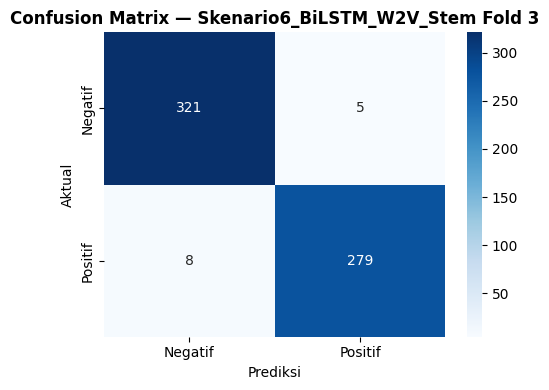

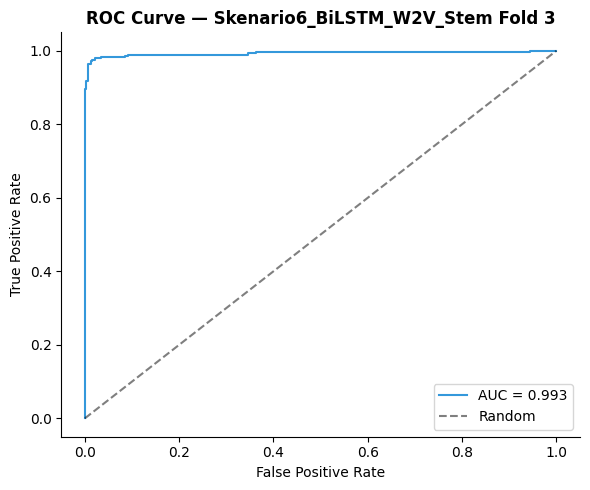


  ── Fold 4/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 33s 259ms/step - accuracy: 0.7729 - auc: 0.8694 - loss: 0.5256 - val_accuracy: 0.9054 - val_auc: 0.9633 - val_loss: 0.3010
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 250ms/step - accuracy: 0.9148 - auc: 0.9650 - loss: 0.2773 - val_accuracy: 0.9184 - val_auc: 0.9729 - val_loss: 0.2452
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 21s 266ms/step - accuracy: 0.9274 - auc: 0.9734 - loss: 0.2364 - val_accuracy: 0.9250 - val_auc: 0.9790 - val_loss: 0.2195
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 242ms/step - accuracy: 0.9278 - auc: 0.9767 - loss: 0.2195 - val_accuracy: 0.9347 - val_auc: 0.9811 - val_loss: 0.2008
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 241ms/step - accuracy: 0.9425 - auc: 0.9845 - loss: 0.1796 - val_accuracy: 0.9494 - val_auc: 0.9866 - val_loss: 0.1679
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 23s 271ms/step - accuracy: 0.9499 - auc: 0.9852 - loss: 0.1722 - val_accuracy: 0.9413 - val_auc: 0.9

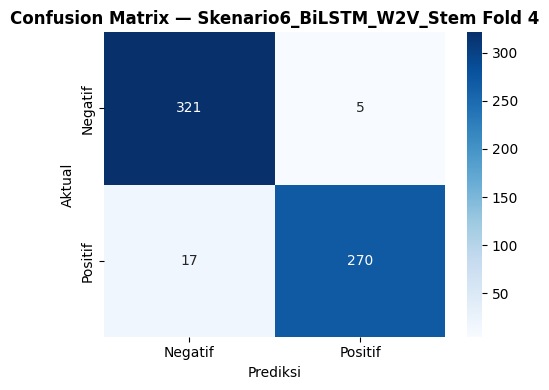

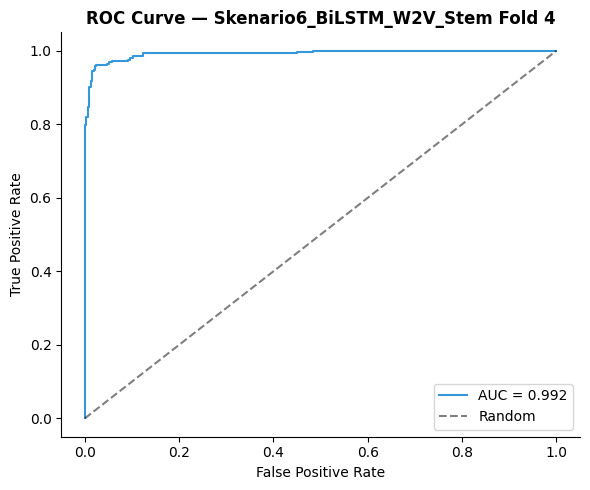


  ── Fold 5/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 29s 261ms/step - accuracy: 0.8055 - auc: 0.8887 - loss: 0.5050 - val_accuracy: 0.9266 - val_auc: 0.9834 - val_loss: 0.2345
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 246ms/step - accuracy: 0.9164 - auc: 0.9596 - loss: 0.2923 - val_accuracy: 0.9315 - val_auc: 0.9863 - val_loss: 0.1979
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 22s 263ms/step - accuracy: 0.9283 - auc: 0.9737 - loss: 0.2353 - val_accuracy: 0.9396 - val_auc: 0.9882 - val_loss: 0.1845
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 241ms/step - accuracy: 0.9360 - auc: 0.9761 - loss: 0.2169 - val_accuracy: 0.9527 - val_auc: 0.9917 - val_loss: 0.1486
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 244ms/step - accuracy: 0.9409 - auc: 0.9801 - loss: 0.1969 - val_accuracy: 0.9657 - val_auc: 0.9947 - val_loss: 0.1202
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 242ms/step - accuracy: 0.9543 - auc: 0.9862 - loss: 0.1628 - val_accuracy: 0.9690 - val_auc: 0.9

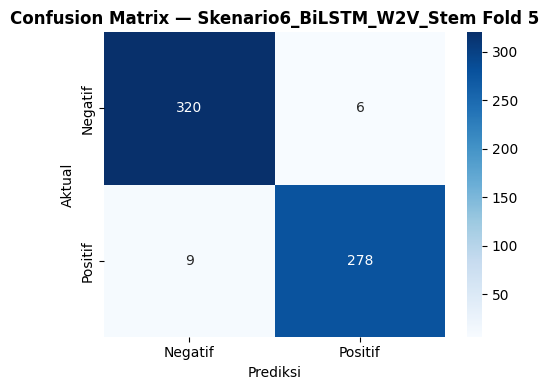

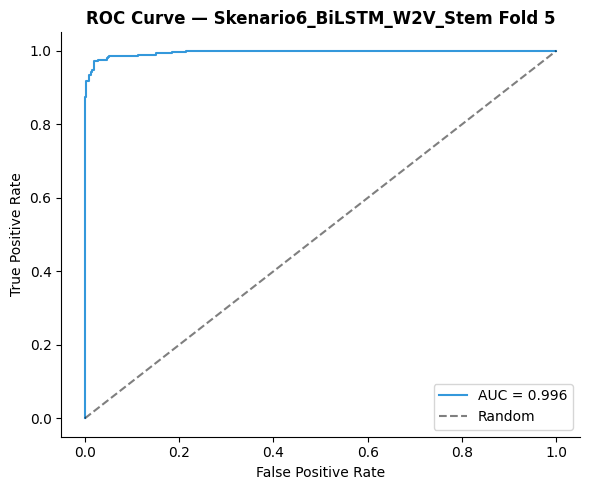


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task2_Room/Skenario6_BiLSTM_W2V_Stem/model.h5


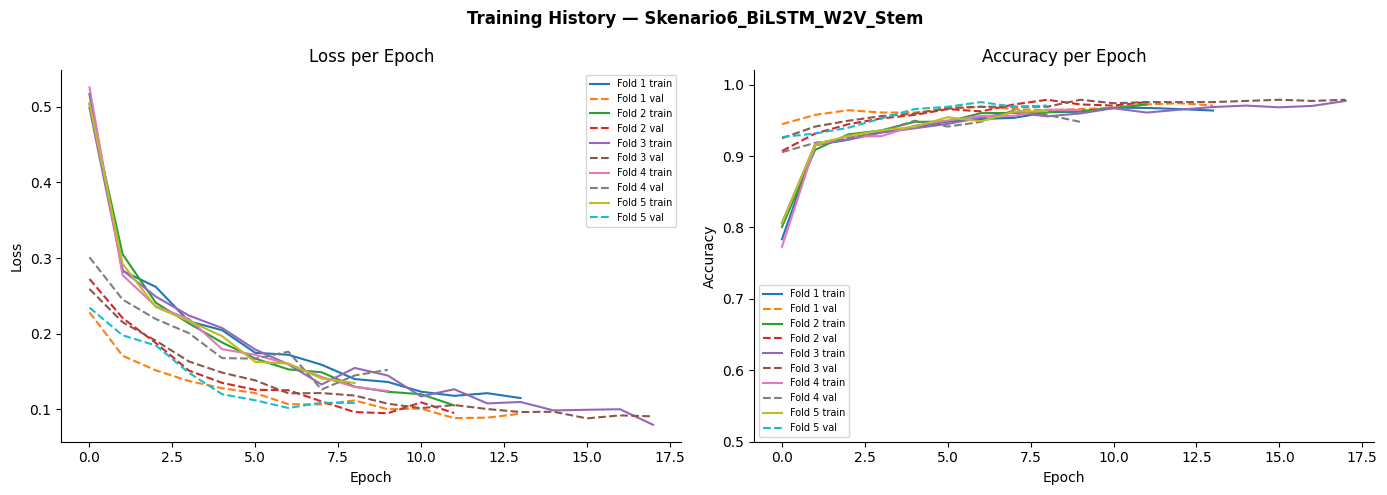


  ╔═ SELESAI: Skenario6_BiLSTM_W2V_Stem
  ║  avg Precision  : 0.9732 ± 0.0049
  ║  avg Recall     : 0.9719 ± 0.0059
  ║  avg F1 Macro   : 0.9725 ± 0.0055
  ║  avg Accuracy   : 0.9726 ± 0.0055
  ║  avg AUC        : 0.9946 ± 0.0020
  ║  avg RAM        : 3571.9 MB (27.5%)
  ║  avg CPU        : 13.4 %
  ║  avg Waktu      : 258.26 detik/fold
  ║  avg T/Epoch    : 20.54 detik/epoch
  ║  avg T/Step     : 0.2702 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 6 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[5])


  Training: Skenario7_BiLSTM_FT_NonStem
  Membuat embedding matrix...
  Vocab tokenizer : 5,546 kata
  OOV             : 0 kata tidak ditemukan di embedding
  Shape matrix    : (5546, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1148, Neg=1304
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 29s 280ms/step - accuracy: 0.7655 - auc: 0.8649 - loss: 0.5364 - val_accuracy: 0.9267 - val_auc: 0.9846 - val_loss: 0.2489
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 18s 236ms/step - accuracy: 0.8972 - auc: 0.9504 - loss: 0.3285 - val_accuracy: 0.9332 - val_auc: 0.9893 - val_loss: 0.2070
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 18s 235ms/step - accuracy: 0.9148 - auc: 0.9708 - loss: 0.2563 - val_accuracy: 0.9528 - val_auc: 0.9933 - val_loss: 0.1529
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 247ms/step - accuracy: 0.9335 - auc: 0.9769 - loss: 0.2209 - val_accuracy: 0.9739 - val_auc: 0.9955 - val_loss: 0.1221
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 250ms/step - accuracy: 0.9458 - auc: 0.9830 - loss: 0.1842 - val_ac

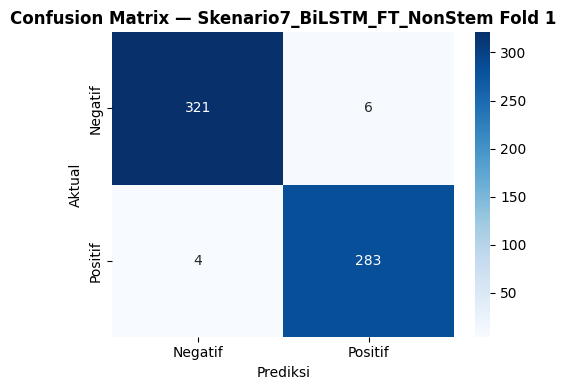

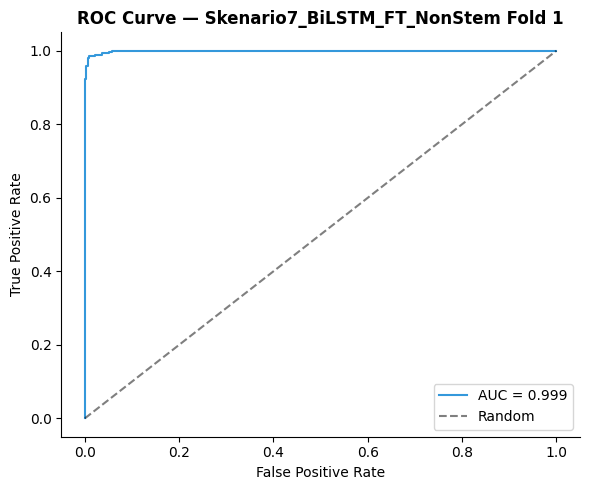


  ── Fold 2/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 31s 269ms/step - accuracy: 0.8129 - auc: 0.8940 - loss: 0.4896 - val_accuracy: 0.9168 - val_auc: 0.9739 - val_loss: 0.2897
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 256ms/step - accuracy: 0.9026 - auc: 0.9561 - loss: 0.3101 - val_accuracy: 0.9266 - val_auc: 0.9803 - val_loss: 0.2304
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 241ms/step - accuracy: 0.9144 - auc: 0.9636 - loss: 0.2764 - val_accuracy: 0.9396 - val_auc: 0.9843 - val_loss: 0.2047
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 21s 248ms/step - accuracy: 0.9291 - auc: 0.9723 - loss: 0.2381 - val_accuracy: 0.9462 - val_auc: 0.9891 - val_loss: 0.1664
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 21s 259ms/step - accuracy: 0.9421 - auc: 0.9802 - loss: 0.2014 - val_accuracy: 0.9592 - val_auc: 0.9887 - val_loss: 0.1544
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 250ms/step - accuracy: 0.9486 - auc: 0.9809 - loss: 0.1941 - val_accuracy: 0.9706 - val_auc: 0.9

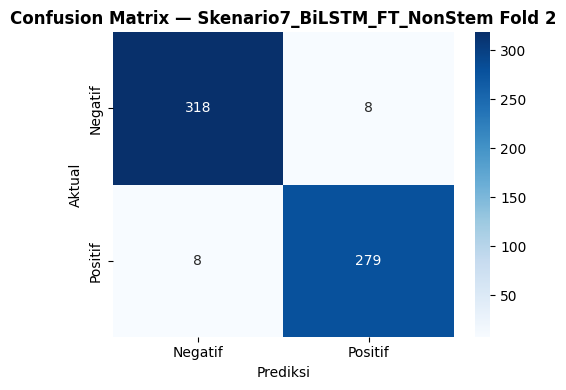

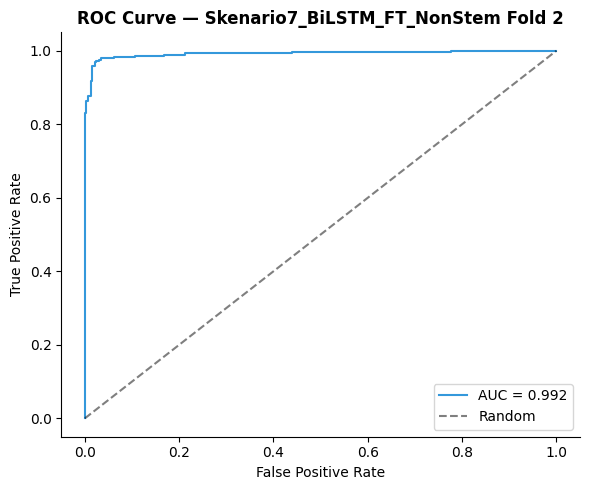


  ── Fold 3/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 28s 260ms/step - accuracy: 0.7852 - auc: 0.8690 - loss: 0.5329 - val_accuracy: 0.9315 - val_auc: 0.9666 - val_loss: 0.2831
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 21s 260ms/step - accuracy: 0.9050 - auc: 0.9589 - loss: 0.3027 - val_accuracy: 0.9364 - val_auc: 0.9767 - val_loss: 0.2331
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 18s 240ms/step - accuracy: 0.9185 - auc: 0.9683 - loss: 0.2574 - val_accuracy: 0.9347 - val_auc: 0.9792 - val_loss: 0.2063
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 241ms/step - accuracy: 0.9323 - auc: 0.9763 - loss: 0.2213 - val_accuracy: 0.9494 - val_auc: 0.9830 - val_loss: 0.1824
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 22s 264ms/step - accuracy: 0.9425 - auc: 0.9830 - loss: 0.1916 - val_accuracy: 0.9511 - val_auc: 0.9855 - val_loss: 0.1660
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 245ms/step - accuracy: 0.9519 - auc: 0.9854 - loss: 0.1713 - val_accuracy: 0.9576 - val_auc: 0.9

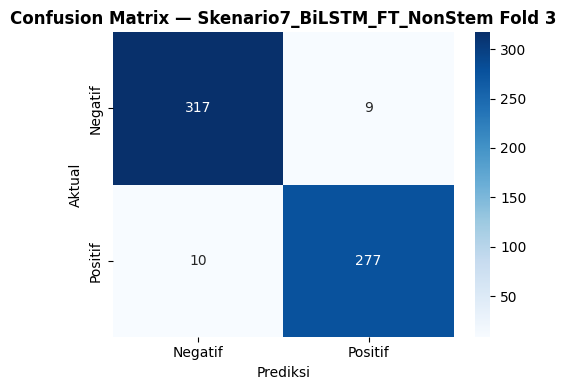

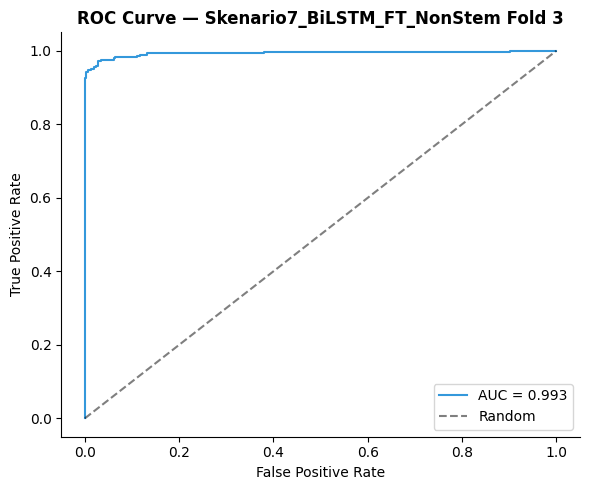


  ── Fold 4/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 29s 269ms/step - accuracy: 0.7754 - auc: 0.8692 - loss: 0.5296 - val_accuracy: 0.9233 - val_auc: 0.9696 - val_loss: 0.2801
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 39s 249ms/step - accuracy: 0.9132 - auc: 0.9598 - loss: 0.2917 - val_accuracy: 0.9299 - val_auc: 0.9748 - val_loss: 0.2535
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 21s 251ms/step - accuracy: 0.9262 - auc: 0.9714 - loss: 0.2470 - val_accuracy: 0.9364 - val_auc: 0.9814 - val_loss: 0.2015
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 240ms/step - accuracy: 0.9389 - auc: 0.9800 - loss: 0.2026 - val_accuracy: 0.9511 - val_auc: 0.9850 - val_loss: 0.1751
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 21s 246ms/step - accuracy: 0.9486 - auc: 0.9852 - loss: 0.1773 - val_accuracy: 0.9494 - val_auc: 0.9828 - val_loss: 0.1863
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 260ms/step - accuracy: 0.9478 - auc: 0.9847 - loss: 0.1754 - val_accuracy: 0.9592 - val_auc: 0.9

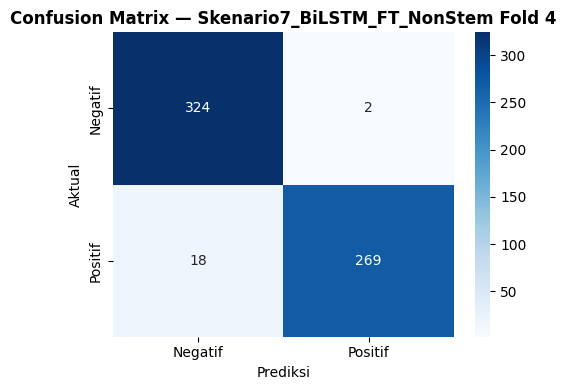

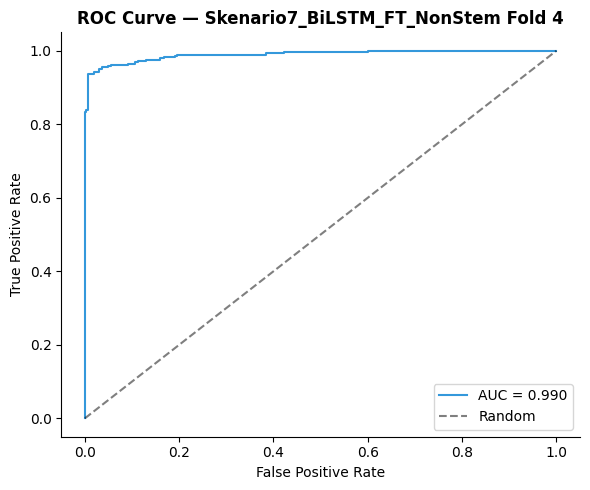


  ── Fold 5/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 29s 271ms/step - accuracy: 0.7933 - auc: 0.8832 - loss: 0.5141 - val_accuracy: 0.9201 - val_auc: 0.9808 - val_loss: 0.2488
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 40s 264ms/step - accuracy: 0.9103 - auc: 0.9617 - loss: 0.2996 - val_accuracy: 0.9347 - val_auc: 0.9850 - val_loss: 0.2150
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 240ms/step - accuracy: 0.9181 - auc: 0.9706 - loss: 0.2603 - val_accuracy: 0.9494 - val_auc: 0.9902 - val_loss: 0.1731
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 239ms/step - accuracy: 0.9340 - auc: 0.9778 - loss: 0.2221 - val_accuracy: 0.9543 - val_auc: 0.9912 - val_loss: 0.1625
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 243ms/step - accuracy: 0.9417 - auc: 0.9800 - loss: 0.2046 - val_accuracy: 0.9527 - val_auc: 0.9925 - val_loss: 0.1487
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 22s 256ms/step - accuracy: 0.9474 - auc: 0.9825 - loss: 0.1883 - val_accuracy: 0.9608 - val_auc: 0.9

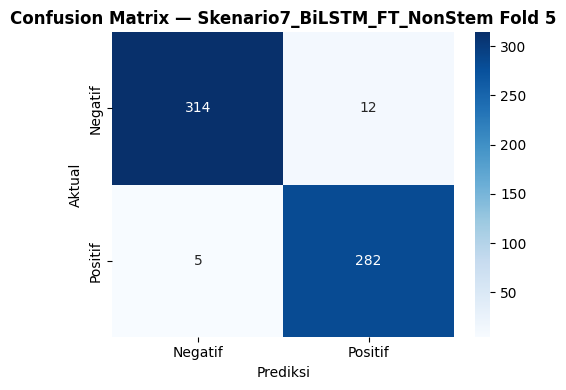

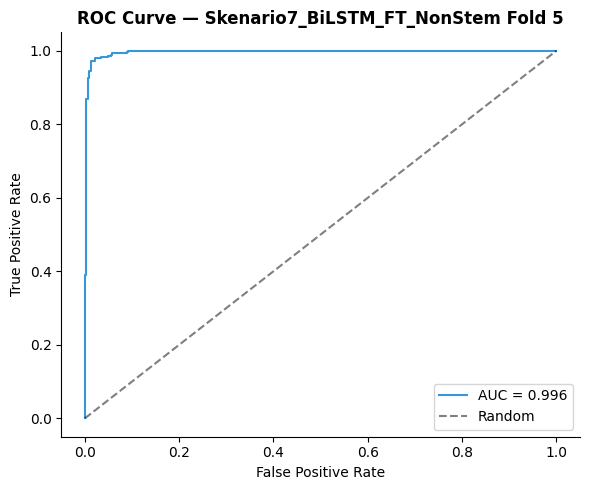


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task2_Room/Skenario7_BiLSTM_FT_NonStem/model.h5


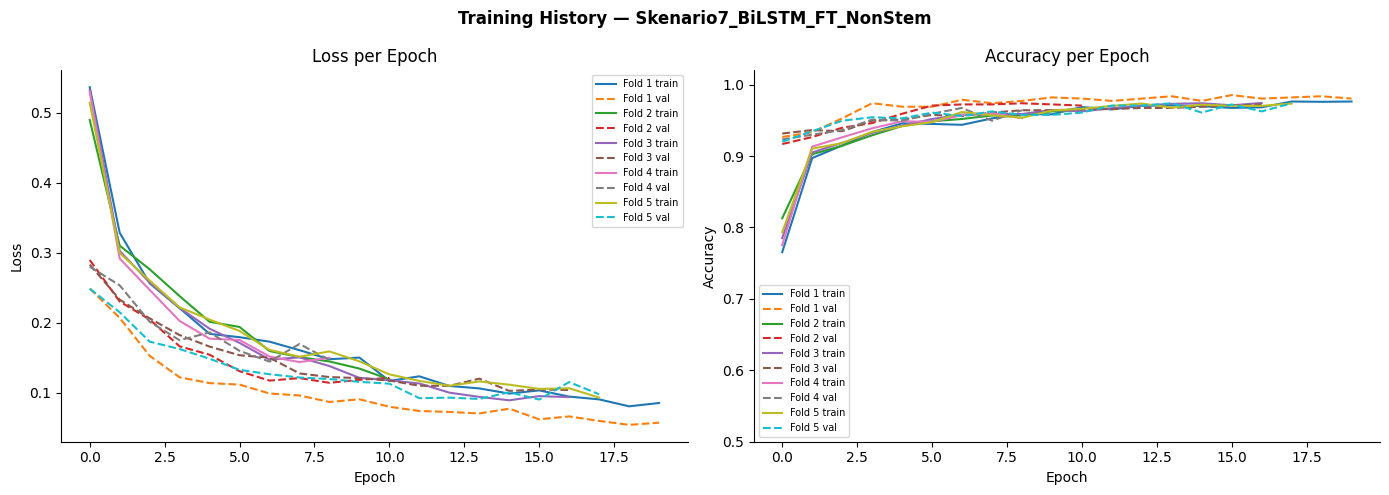


  ╔═ SELESAI: Skenario7_BiLSTM_FT_NonStem
  ║  avg Precision  : 0.9736 ± 0.0058
  ║  avg Recall     : 0.9730 ± 0.0069
  ║  avg F1 Macro   : 0.9731 ± 0.0064
  ║  avg Accuracy   : 0.9733 ± 0.0064
  ║  avg AUC        : 0.9940 ± 0.0037
  ║  avg RAM        : 3928.8 MB (30.3%)
  ║  avg CPU        : 3.3 %
  ║  avg Waktu      : 322.58 detik/fold
  ║  avg T/Epoch    : 21.77 detik/epoch
  ║  avg T/Step     : 0.2865 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 7 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[6])


  Training: Skenario8_BiLSTM_FT_Stem
  Membuat embedding matrix...
  Vocab tokenizer : 3,812 kata
  OOV             : 0 kata tidak ditemukan di embedding
  Shape matrix    : (3812, 100)

  ── Fold 1/5 ──
  Distribusi train: Pos=1148, Neg=1304
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 41s 308ms/step - accuracy: 0.7610 - auc: 0.8556 - loss: 0.5462 - val_accuracy: 0.9283 - val_auc: 0.9843 - val_loss: 0.2417
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 246ms/step - accuracy: 0.8976 - auc: 0.9491 - loss: 0.3228 - val_accuracy: 0.9365 - val_auc: 0.9884 - val_loss: 0.2045
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 249ms/step - accuracy: 0.9164 - auc: 0.9673 - loss: 0.2620 - val_accuracy: 0.9511 - val_auc: 0.9924 - val_loss: 0.1515
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 244ms/step - accuracy: 0.9294 - auc: 0.9704 - loss: 0.2394 - val_accuracy: 0.9528 - val_auc: 0.9933 - val_loss: 0.1495
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 22s 260ms/step - accuracy: 0.9303 - auc: 0.9768 - loss: 0.2170 - val_accur

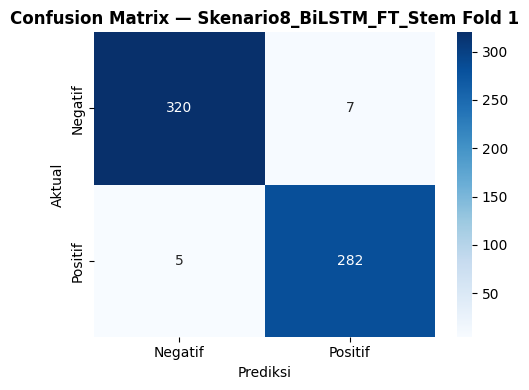

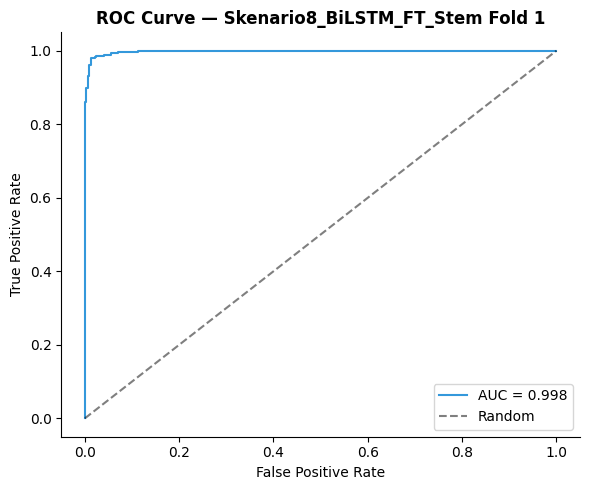


  ── Fold 2/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 29s 266ms/step - accuracy: 0.7542 - auc: 0.8483 - loss: 0.5549 - val_accuracy: 0.9119 - val_auc: 0.9708 - val_loss: 0.3046
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 39s 246ms/step - accuracy: 0.8952 - auc: 0.9534 - loss: 0.3162 - val_accuracy: 0.9152 - val_auc: 0.9785 - val_loss: 0.2406
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 22s 266ms/step - accuracy: 0.9172 - auc: 0.9662 - loss: 0.2613 - val_accuracy: 0.9250 - val_auc: 0.9849 - val_loss: 0.2002
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 244ms/step - accuracy: 0.9291 - auc: 0.9749 - loss: 0.2255 - val_accuracy: 0.9462 - val_auc: 0.9871 - val_loss: 0.1744
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 18s 238ms/step - accuracy: 0.9344 - auc: 0.9757 - loss: 0.2151 - val_accuracy: 0.9511 - val_auc: 0.9894 - val_loss: 0.1583
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 18s 240ms/step - accuracy: 0.9413 - auc: 0.9806 - loss: 0.1926 - val_accuracy: 0.9690 - val_auc: 0.9

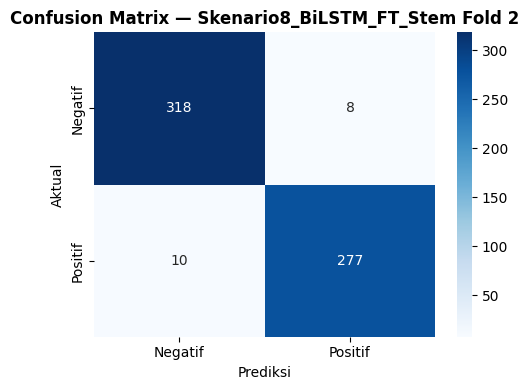

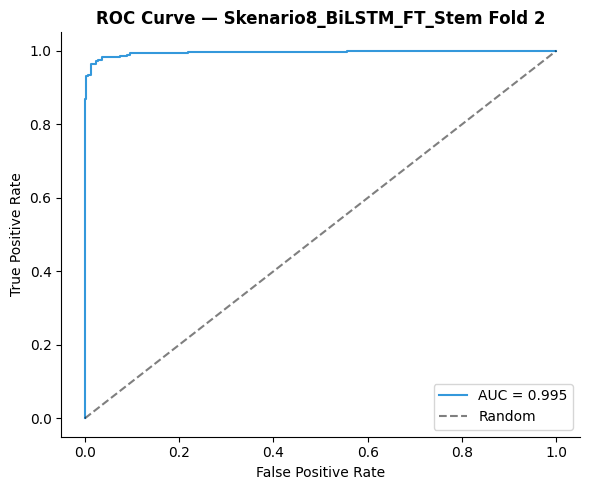


  ── Fold 3/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 30s 274ms/step - accuracy: 0.7689 - auc: 0.8626 - loss: 0.5355 - val_accuracy: 0.9168 - val_auc: 0.9667 - val_loss: 0.2938
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 41s 277ms/step - accuracy: 0.8973 - auc: 0.9536 - loss: 0.3180 - val_accuracy: 0.9266 - val_auc: 0.9729 - val_loss: 0.2555
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 249ms/step - accuracy: 0.9189 - auc: 0.9698 - loss: 0.2564 - val_accuracy: 0.9347 - val_auc: 0.9775 - val_loss: 0.2116
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 244ms/step - accuracy: 0.9258 - auc: 0.9736 - loss: 0.2327 - val_accuracy: 0.9445 - val_auc: 0.9804 - val_loss: 0.1966
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 242ms/step - accuracy: 0.9352 - auc: 0.9789 - loss: 0.2074 - val_accuracy: 0.9494 - val_auc: 0.9839 - val_loss: 0.1827
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 23s 268ms/step - accuracy: 0.9417 - auc: 0.9819 - loss: 0.1925 - val_accuracy: 0.9560 - val_auc: 0.9

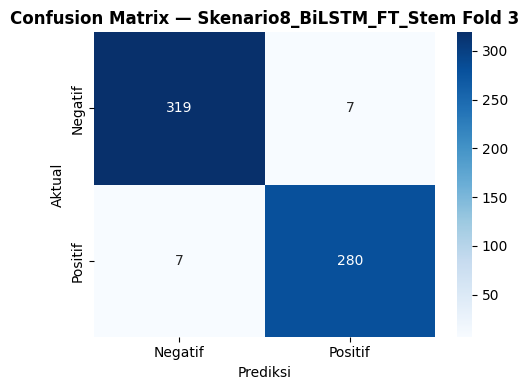

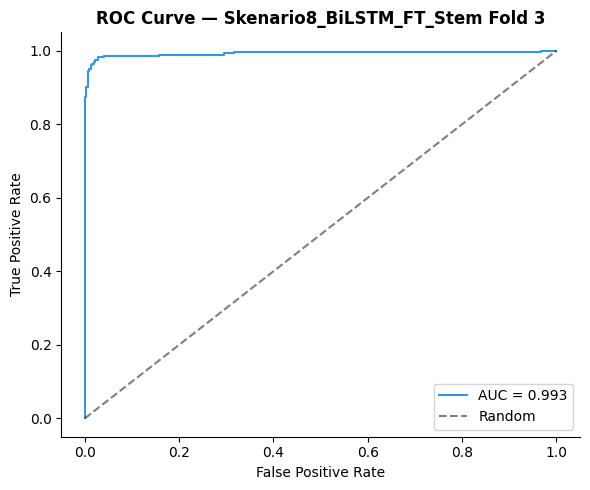


  ── Fold 4/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 30s 266ms/step - accuracy: 0.7750 - auc: 0.8666 - loss: 0.5365 - val_accuracy: 0.9086 - val_auc: 0.9628 - val_loss: 0.3136
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 39s 240ms/step - accuracy: 0.9022 - auc: 0.9558 - loss: 0.3086 - val_accuracy: 0.9152 - val_auc: 0.9737 - val_loss: 0.2564
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 247ms/step - accuracy: 0.9213 - auc: 0.9697 - loss: 0.2496 - val_accuracy: 0.9217 - val_auc: 0.9803 - val_loss: 0.2197
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 22s 282ms/step - accuracy: 0.9262 - auc: 0.9740 - loss: 0.2299 - val_accuracy: 0.9282 - val_auc: 0.9813 - val_loss: 0.2020
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 18s 239ms/step - accuracy: 0.9287 - auc: 0.9740 - loss: 0.2260 - val_accuracy: 0.9396 - val_auc: 0.9854 - val_loss: 0.1729
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 246ms/step - accuracy: 0.9429 - auc: 0.9793 - loss: 0.1951 - val_accuracy: 0.9347 - val_auc: 0.9

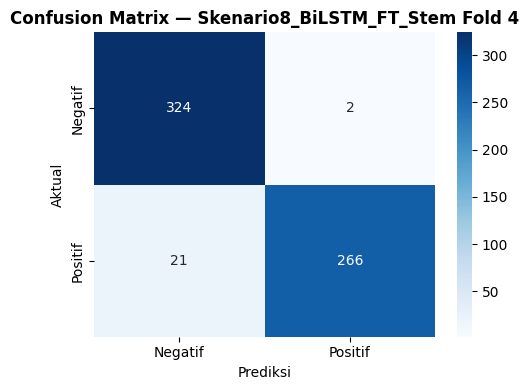

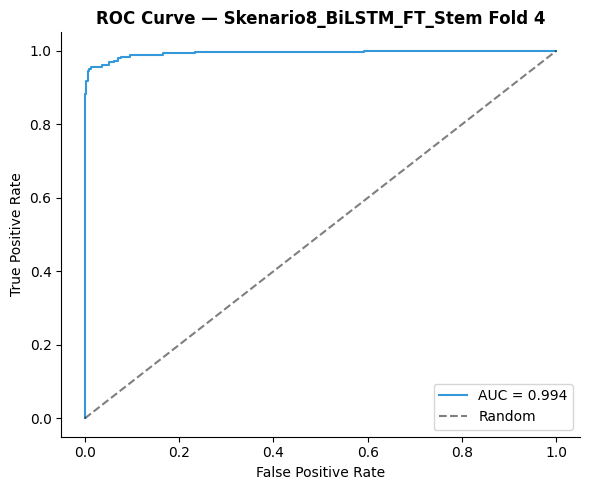


  ── Fold 5/5 ──
  Distribusi train: Pos=1148, Neg=1305
Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 29s 260ms/step - accuracy: 0.7778 - auc: 0.8745 - loss: 0.5227 - val_accuracy: 0.9103 - val_auc: 0.9789 - val_loss: 0.2667
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 258ms/step - accuracy: 0.8985 - auc: 0.9553 - loss: 0.3151 - val_accuracy: 0.9347 - val_auc: 0.9832 - val_loss: 0.2234
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 246ms/step - accuracy: 0.9160 - auc: 0.9632 - loss: 0.2814 - val_accuracy: 0.9494 - val_auc: 0.9890 - val_loss: 0.1794
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 242ms/step - accuracy: 0.9315 - auc: 0.9737 - loss: 0.2360 - val_accuracy: 0.9445 - val_auc: 0.9911 - val_loss: 0.1589
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 23s 272ms/step - accuracy: 0.9368 - auc: 0.9753 - loss: 0.2206 - val_accuracy: 0.9576 - val_auc: 0.9930 - val_loss: 0.1422
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 39s 244ms/step - accuracy: 0.9409 - auc: 0.9785 - loss: 0.1983 - val_accuracy: 0.9657 - val_auc: 0.9

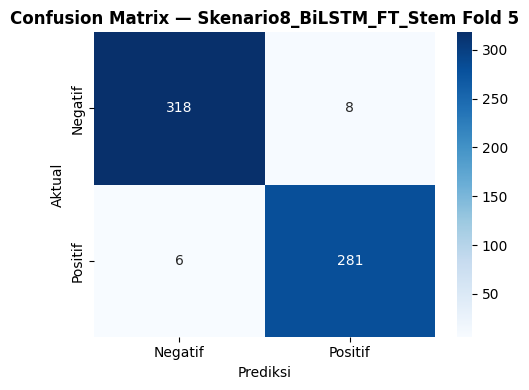

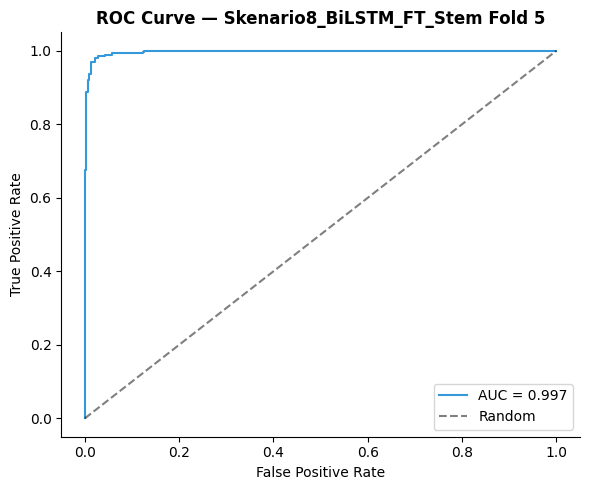


  Model disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task2_Room/Skenario8_BiLSTM_FT_Stem/model.h5


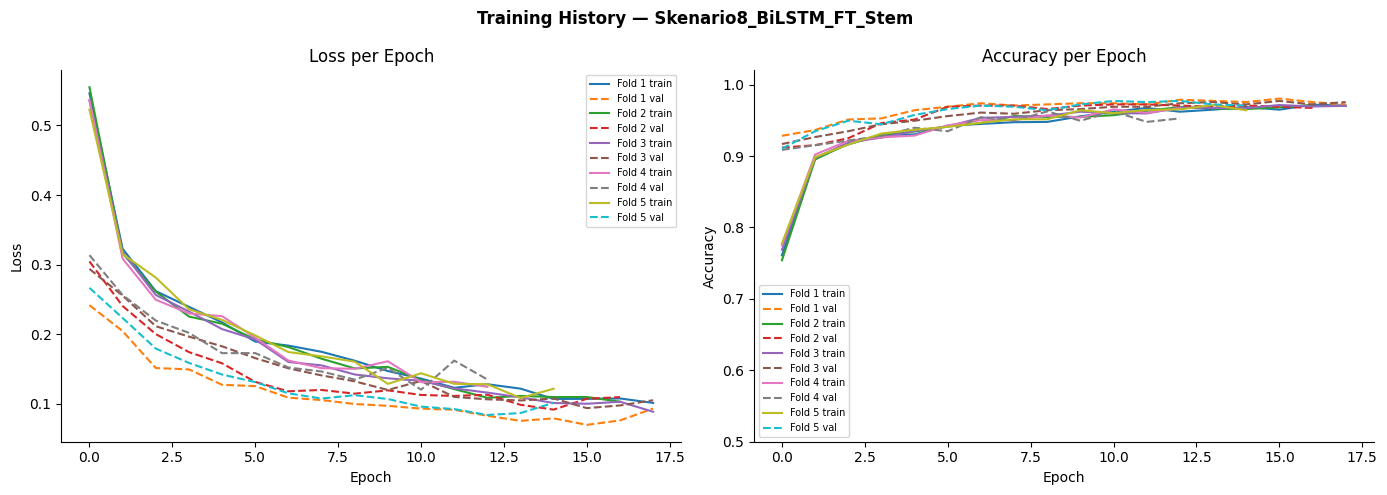


  ╔═ SELESAI: Skenario8_BiLSTM_FT_Stem
  ║  avg Precision  : 0.9741 ± 0.0058
  ║  avg Recall     : 0.9731 ± 0.0081
  ║  avg F1 Macro   : 0.9734 ± 0.0073
  ║  avg Accuracy   : 0.9736 ± 0.0072
  ║  avg AUC        : 0.9954 ± 0.0021
  ║  avg RAM        : 4179.2 MB (32.2%)
  ║  avg CPU        : 8.4 %
  ║  avg Waktu      : 356.97 detik/fold
  ║  avg T/Epoch    : 21.77 detik/epoch
  ║  avg T/Step     : 0.2864 detik/step
  ╚══════════════════════════════════════════════════


In [ ]:
# ── Skenario 8 ── ini pakai epoch max 20, l2=0.001
jalankan_skenario(skenario_list[7])

## 8. Rekap Hasil & Simpan ke Excel


In [ ]:
# Load rekap CSV lalu simpan ke Excel
df_rekap = pd.read_csv(OUTPUT_DIR + 'rekap_Task2_semua_skenario.csv')

# Urutkan berdasarkan F1 Macro tertinggi
df_rekap = df_rekap.sort_values('avg_f1_macro', ascending=False).reset_index(drop=True)

print('=== Rekap Semua Skenario (urut F1 Macro) ===')
cols_tampil = ['skenario', 'avg_f1_macro', 'std_f1_macro',
               'avg_accuracy', 'avg_precision_macro',
               'avg_recall_macro', 'avg_auc']
print(df_rekap[cols_tampil].to_string(index=False))

# Simpan ke Excel
excel_path = OUTPUT_DIR + 'rekap_Task2_semua_skenario.xlsx'
df_rekap.to_excel(excel_path, index=False)
print(f'\nDisimpan ke: {excel_path}')

=== Rekap Semua Skenario (urut F1 Macro) ===
                    skenario  avg_f1_macro  std_f1_macro  avg_accuracy  avg_precision_macro  avg_recall_macro  avg_auc
   Skenario1_CNN_W2V_NonStem        0.9784        0.0076        0.9785               0.9787            0.9781   0.9965
       Skenario4_CNN_FT_Stem        0.9784        0.0018        0.9785               0.9783            0.9786   0.9960
      Skenario2_CNN_W2V_Stem        0.9781        0.0051        0.9781               0.9779            0.9782   0.9965
    Skenario3_CNN_FT_NonStem        0.9771        0.0074        0.9772               0.9773            0.9769   0.9963
    Skenario8_BiLSTM_FT_Stem        0.9734        0.0073        0.9736               0.9741            0.9731   0.9954
 Skenario7_BiLSTM_FT_NonStem        0.9731        0.0064        0.9733               0.9736            0.9730   0.9940
   Skenario6_BiLSTM_W2V_Stem        0.9725        0.0055        0.9726               0.9732            0.9719   0.9946
Ske

In [ ]:
# Load rekap CSV lalu simpan ke Excel
df_rekap = pd.read_csv(OUTPUT_DIR + 'rekap_Task2_semua_skenario.csv')

# Urutkan berdasarkan F1 Macro tertinggi
df_rekap = df_rekap.sort_values('avg_f1_macro', ascending=False).reset_index(drop=True)
df_rekap.insert(0, 'rank', range(1, len(df_rekap) + 1))

print('='*100)
print('  REKAP SEMUA SKENARIO TASK 2 — SENTIMEN ROOM')
print('  Diurutkan berdasarkan F1 Macro Tertinggi')
print('='*100)

# Tampilkan per kelompok metrik
cols_utama = ['rank', 'skenario',
              'avg_f1_macro', 'std_f1_macro',
              'avg_precision_macro', 'std_precision_macro',
              'avg_recall_macro', 'std_recall_macro',
              'avg_accuracy', 'std_accuracy',
              'avg_auc', 'std_auc']

cols_resource = ['rank', 'skenario',
    'avg_waktu_training',  'std_waktu_training',
    'avg_waktu_inference', 'std_waktu_inference',
    'avg_time_per_epoch',  'std_time_per_epoch',
    'avg_time_per_step',   'std_time_per_step',
    'avg_ram_mb',          'std_ram_mb',
    'avg_ram_pct',         'std_ram_pct',
    'avg_cpu_pct',         'std_cpu_pct',
    'avg_epoch_berhenti',  'std_epoch_berhenti']

# Filter kolom yang ada saja
cols_utama    = [c for c in cols_utama    if c in df_rekap.columns]
cols_resource = [c for c in cols_resource if c in df_rekap.columns]

print('\n── Metrik Performa ──')
print(df_rekap[cols_utama].to_string(index=False))

print('\n── Resource Usage ──')
print(df_rekap[cols_resource].to_string(index=False))

# Highlight model terbaik
best = df_rekap.iloc[0]
print('\n' + '='*100)
print(f'     MODEL TERBAIK : {best["skenario"]}')
print(f'     F1 Macro     : {best["avg_f1_macro"]:.4f} ± {best["std_f1_macro"]:.4f}')
print(f'     Precision    : {best["avg_precision_macro"]:.4f} ± {best["std_precision_macro"]:.4f}')
print(f'     Recall       : {best["avg_recall_macro"]:.4f} ± {best["std_recall_macro"]:.4f}')
print(f'     Accuracy     : {best["avg_accuracy"]:.4f} ± {best["std_accuracy"]:.4f}')
print(f'     AUC          : {best["avg_auc"]:.4f} ± {best["std_auc"]:.4f}')
print('='*100)

# Simpan ke Excel dengan formatting
excel_path = OUTPUT_DIR + 'rekap_Task2_semua_skenario.xlsx'

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    # Sheet 1: Semua metrik
    df_rekap.to_excel(writer, sheet_name='Rekap_Lengkap', index=False)

    # Sheet 2: Ringkasan
    cols_ringkasan = [c for c in [
        'rank', 'skenario',
        'avg_f1_macro', 'std_f1_macro',
        'avg_precision_macro', 'avg_recall_macro',
        'avg_accuracy', 'avg_auc',
        'avg_waktu_training', 'avg_ram_mb'
    ] if c in df_rekap.columns]

    df_rekap[cols_ringkasan].to_excel(
        writer, sheet_name='Ringkasan', index=False
    )

print(f'\n✅ Disimpan ke : {excel_path}')

  REKAP SEMUA SKENARIO TASK 2 — SENTIMEN ROOM
  Diurutkan berdasarkan F1 Macro Tertinggi

── Metrik Performa ──
 rank                     skenario  avg_f1_macro  std_f1_macro  avg_precision_macro  std_precision_macro  avg_recall_macro  std_recall_macro  avg_accuracy  std_accuracy  avg_auc  std_auc
    1    Skenario1_CNN_W2V_NonStem        0.9784        0.0076               0.9787               0.0077            0.9781            0.0075        0.9785        0.0076   0.9965   0.0024
    2        Skenario4_CNN_FT_Stem        0.9784        0.0018               0.9783               0.0020            0.9786            0.0018        0.9785        0.0018   0.9960   0.0029
    3       Skenario2_CNN_W2V_Stem        0.9781        0.0051               0.9779               0.0050            0.9782            0.0053        0.9781        0.0051   0.9965   0.0025
    4     Skenario3_CNN_FT_NonStem        0.9771        0.0074               0.9773               0.0073            0.9769            0.0076


Plot: Skenario1_CNN_W2V_NonStem


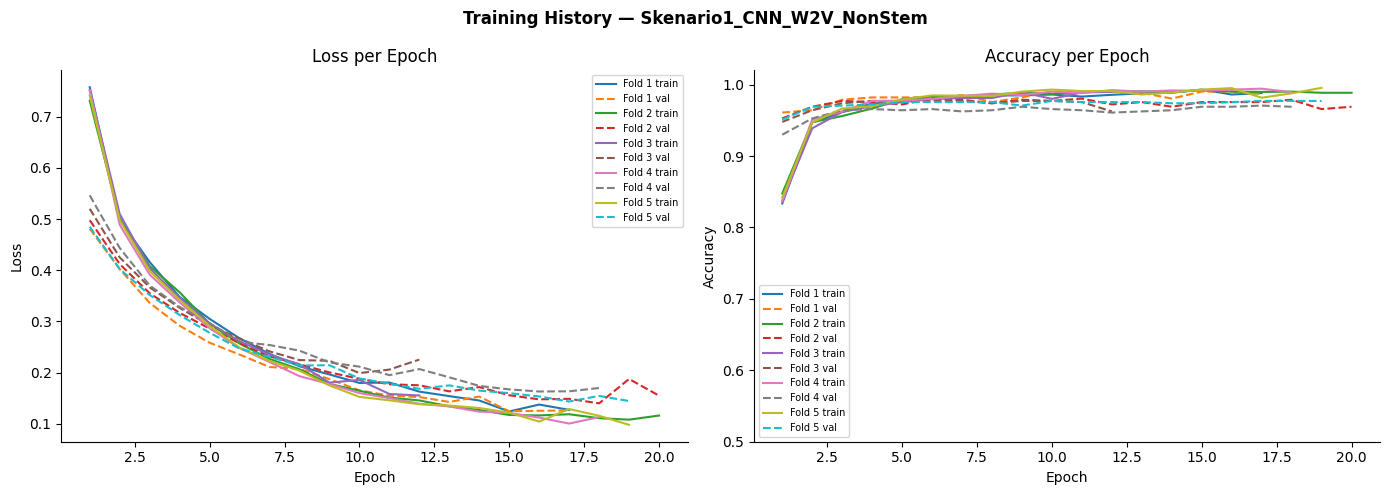

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task2_Room/Skenario1_CNN_W2V_NonStem/training_history_accuracy.png

Plot: Skenario2_CNN_W2V_Stem


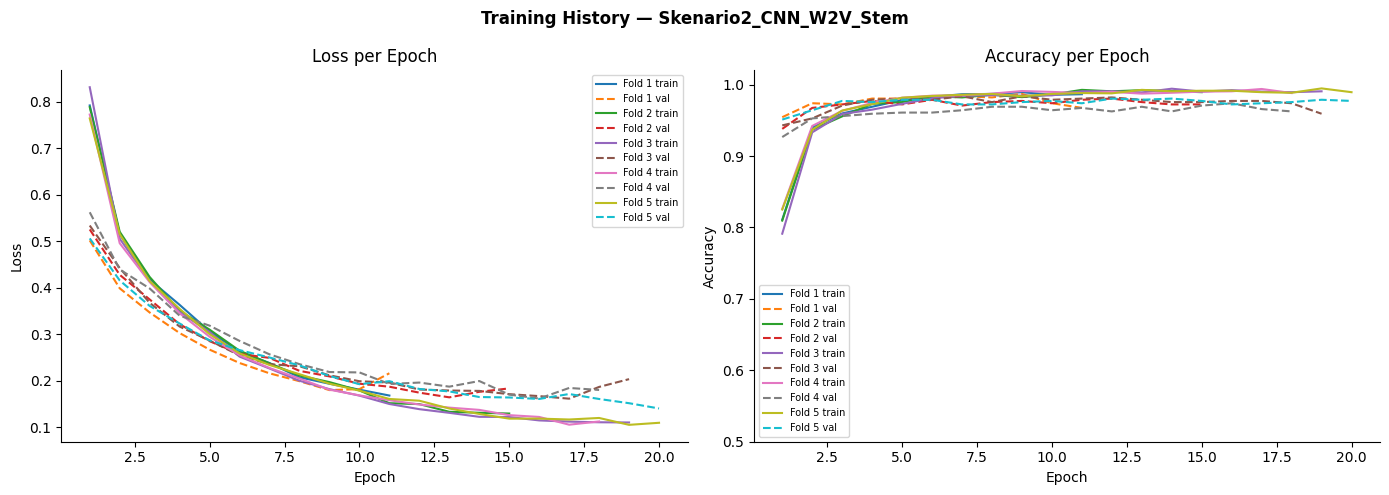

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task2_Room/Skenario2_CNN_W2V_Stem/training_history_accuracy.png

Plot: Skenario3_CNN_FT_NonStem


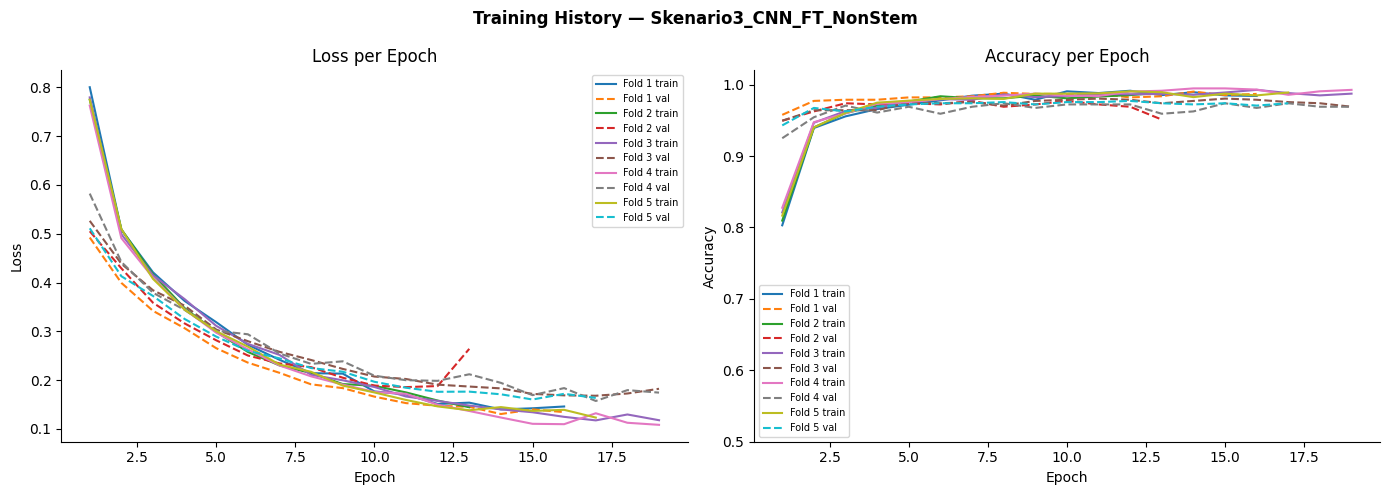

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task2_Room/Skenario3_CNN_FT_NonStem/training_history_accuracy.png

Plot: Skenario4_CNN_FT_Stem


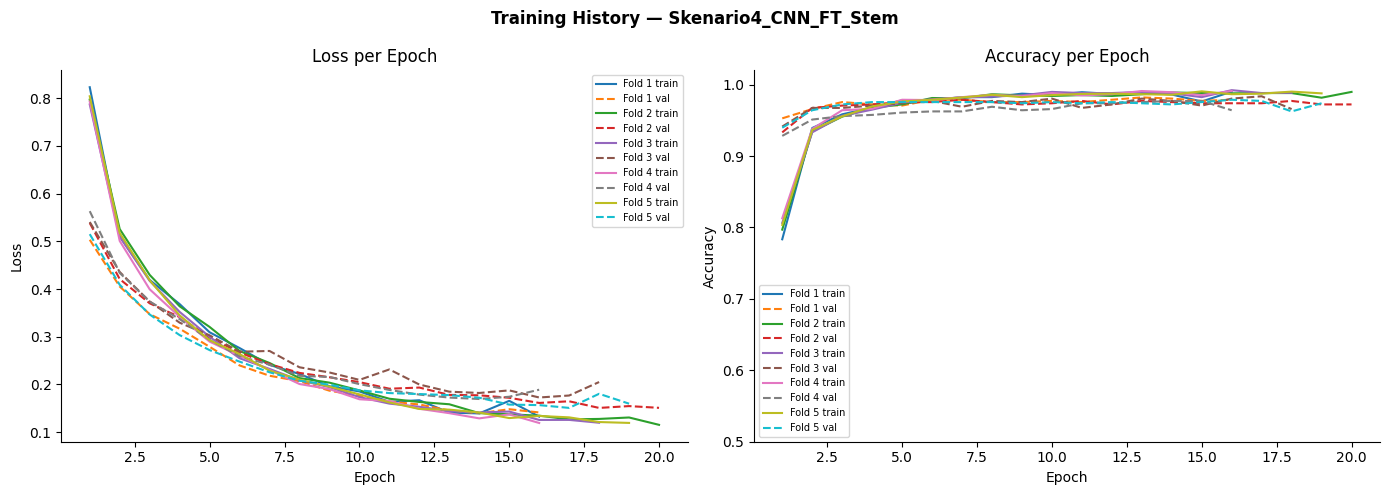

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task2_Room/Skenario4_CNN_FT_Stem/training_history_accuracy.png

Plot: Skenario5_BiLSTM_W2V_NonStem


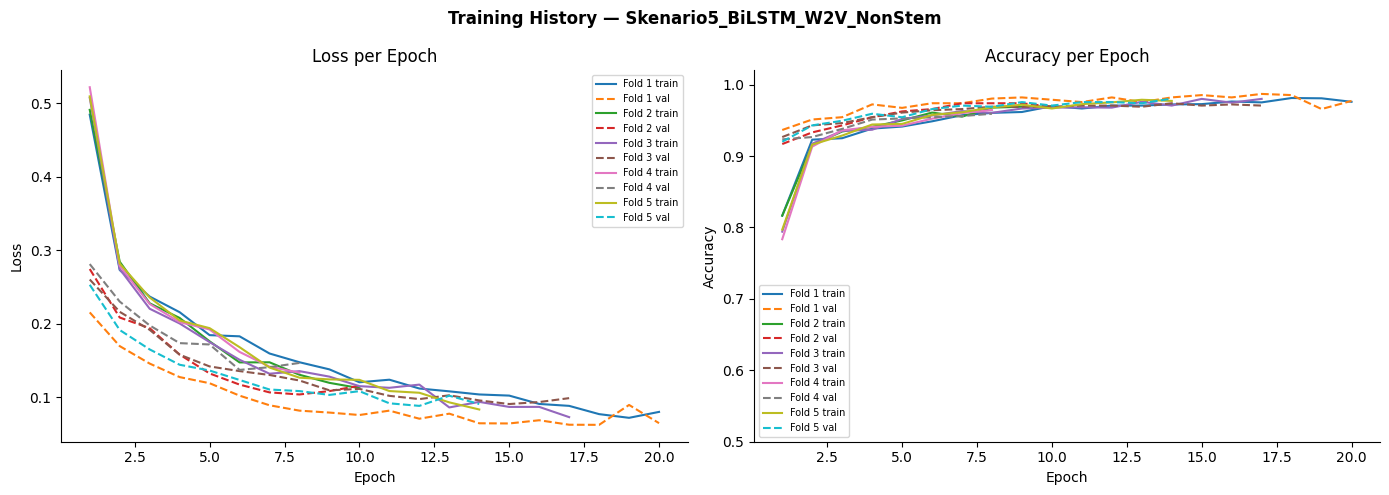

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task2_Room/Skenario5_BiLSTM_W2V_NonStem/training_history_accuracy.png

Plot: Skenario6_BiLSTM_W2V_Stem


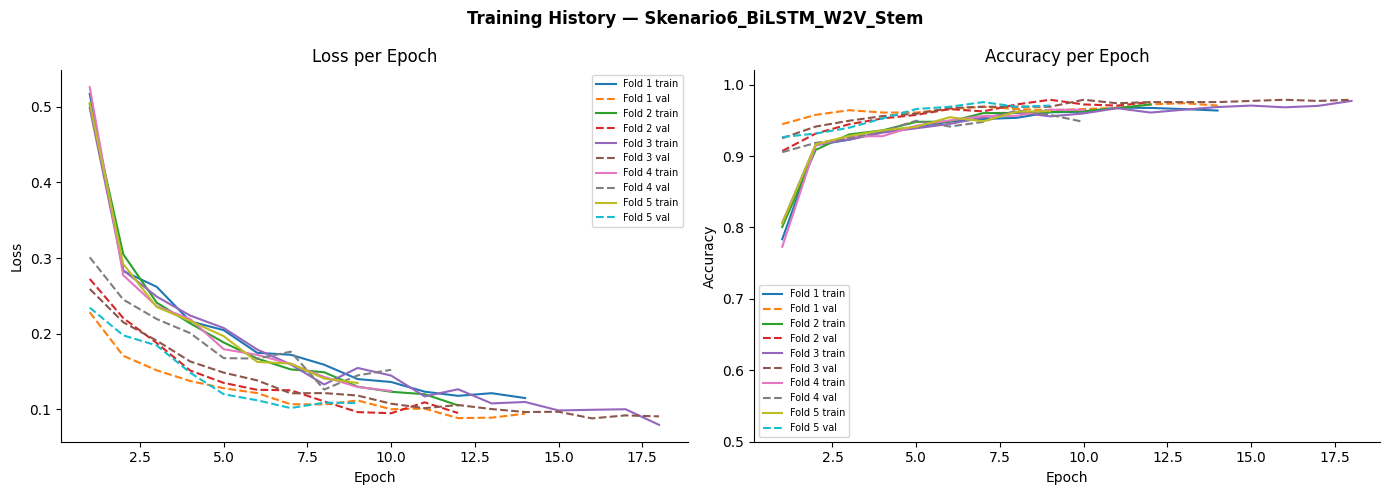

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task2_Room/Skenario6_BiLSTM_W2V_Stem/training_history_accuracy.png

Plot: Skenario7_BiLSTM_FT_NonStem


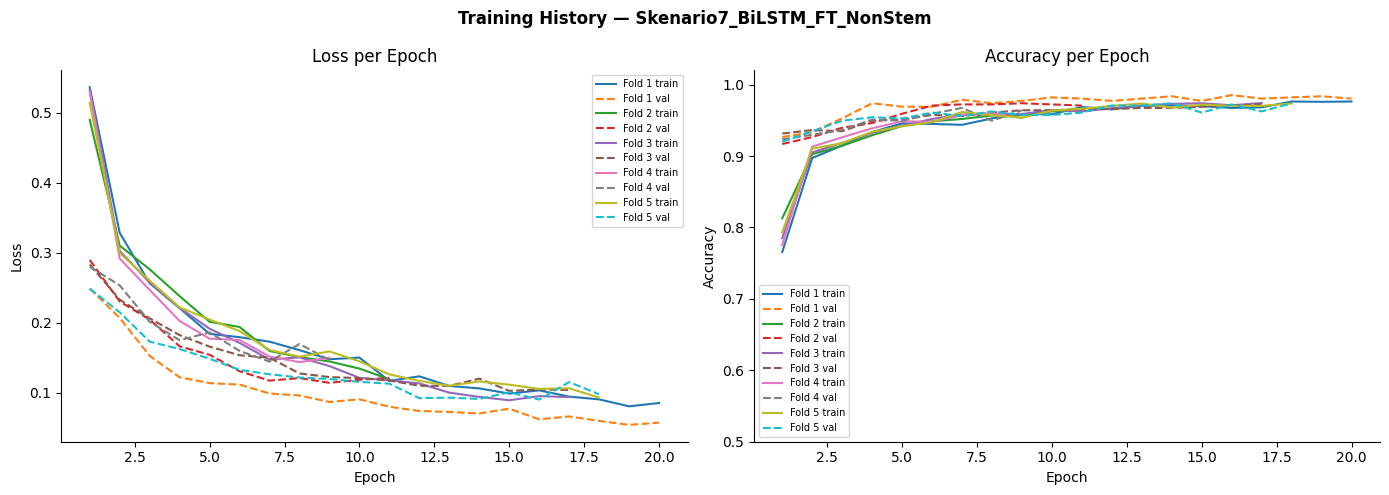

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task2_Room/Skenario7_BiLSTM_FT_NonStem/training_history_accuracy.png

Plot: Skenario8_BiLSTM_FT_Stem


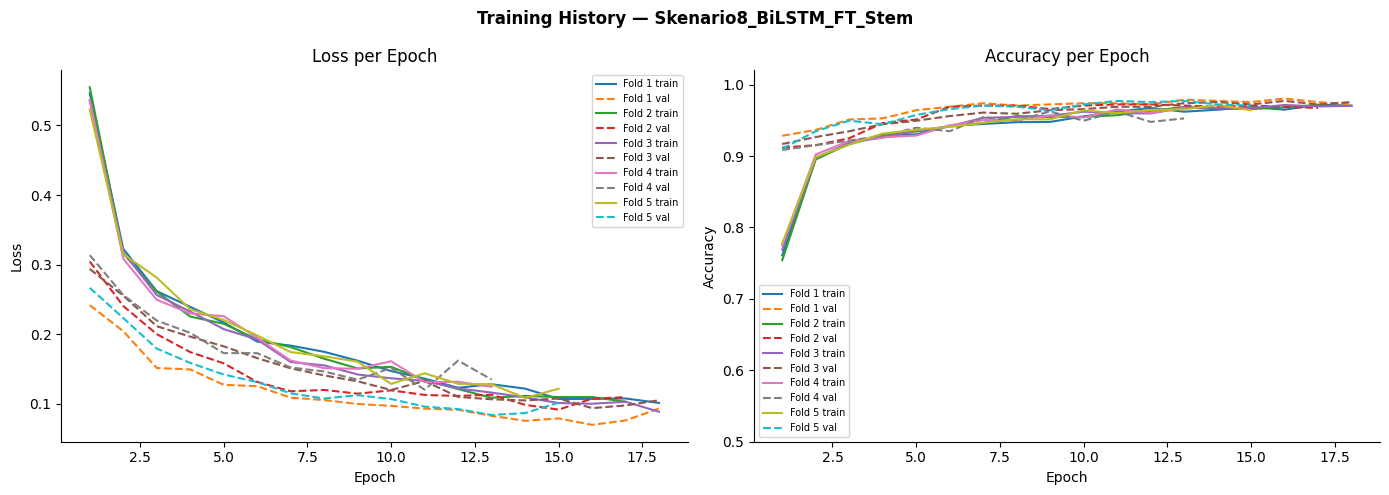

✅ Disimpan: /content/drive/MyDrive/SKRIPSI_NAVY/Dataset/Dataset_Modelling/Task2_Room/Skenario8_BiLSTM_FT_Stem/training_history_accuracy.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_ulang_dari_csv(skenario_dir, nama_skenario):
    # Load history CSV
    df = pd.read_csv(skenario_dir + 'history_per_fold.csv')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for fold_ke in sorted(df['fold'].unique()):
        df_fold = df[df['fold'] == fold_ke]
        label   = f'Fold {fold_ke}'

        # Loss
        axes[0].plot(df_fold['epoch'], df_fold['loss'],
                     linestyle='-',  label=f'{label} train')
        axes[0].plot(df_fold['epoch'], df_fold['val_loss'],
                     linestyle='--', label=f'{label} val')

        # Accuracy
        axes[1].plot(df_fold['epoch'], df_fold['accuracy'],
                     linestyle='-',  label=f'{label} train')
        axes[1].plot(df_fold['epoch'], df_fold['val_accuracy'],
                     linestyle='--', label=f'{label} val')

    axes[0].set_title('Loss per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend(fontsize=7)
    axes[0].spines[['top','right']].set_visible(False)

    axes[1].set_title('Accuracy per Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0.5, 1.02)
    axes[1].legend(fontsize=7)
    axes[1].spines[['top','right']].set_visible(False)

    plt.suptitle(f'Training History — {nama_skenario}', fontweight='bold')
    plt.tight_layout()

    # Simpan
    output_path = skenario_dir + 'training_history_accuracy.png'
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'✅ Disimpan: {output_path}')


# ── Jalankan untuk semua skenario Task 2 ──
BASE_DIR    = '/content/drive/MyDrive/SKRIPSI_NAVY/'
TASK2_DIR   = BASE_DIR + 'Dataset/Dataset_Modelling/Task2_Room/'

skenario_list = [
    'Skenario1_CNN_W2V_NonStem',
    'Skenario2_CNN_W2V_Stem',
    'Skenario3_CNN_FT_NonStem',
    'Skenario4_CNN_FT_Stem',
    'Skenario5_BiLSTM_W2V_NonStem',
    'Skenario6_BiLSTM_W2V_Stem',
    'Skenario7_BiLSTM_FT_NonStem',
    'Skenario8_BiLSTM_FT_Stem',
]

for nama in skenario_list:
    path = TASK2_DIR + nama + '/'
    csv  = path + 'history_per_fold.csv'
    if os.path.exists(csv):
        print(f'\nPlot: {nama}')
        plot_ulang_dari_csv(path, nama)
    else:
        print(f'Skip {nama} — belum ada CSV')

## 9. Rekomendasi Model Terbaik


In [ ]:
# Model terbaik = F1 Macro tertinggi
model_terbaik = df_rekap.iloc[0]
print('=== Model Terbaik Task 2 ===')
print(f"Skenario    : {model_terbaik['skenario']}")
print(f"avg F1 Macro: {model_terbaik['avg_f1_macro']:.4f} ± {model_terbaik['std_f1_macro']:.4f}")
print(f"avg Accuracy: {model_terbaik['avg_accuracy']:.4f}")
print(f"avg AUC     : {model_terbaik['avg_auc']:.4f}")


=== Model Terbaik Task 2 ===
Skenario    : Skenario1_CNN_W2V_NonStem
avg F1 Macro: 0.9784 ± 0.0076
avg Accuracy: 0.9785
avg AUC     : 0.9965


## 10. Visualisasi Perbandingan Semua Skenario


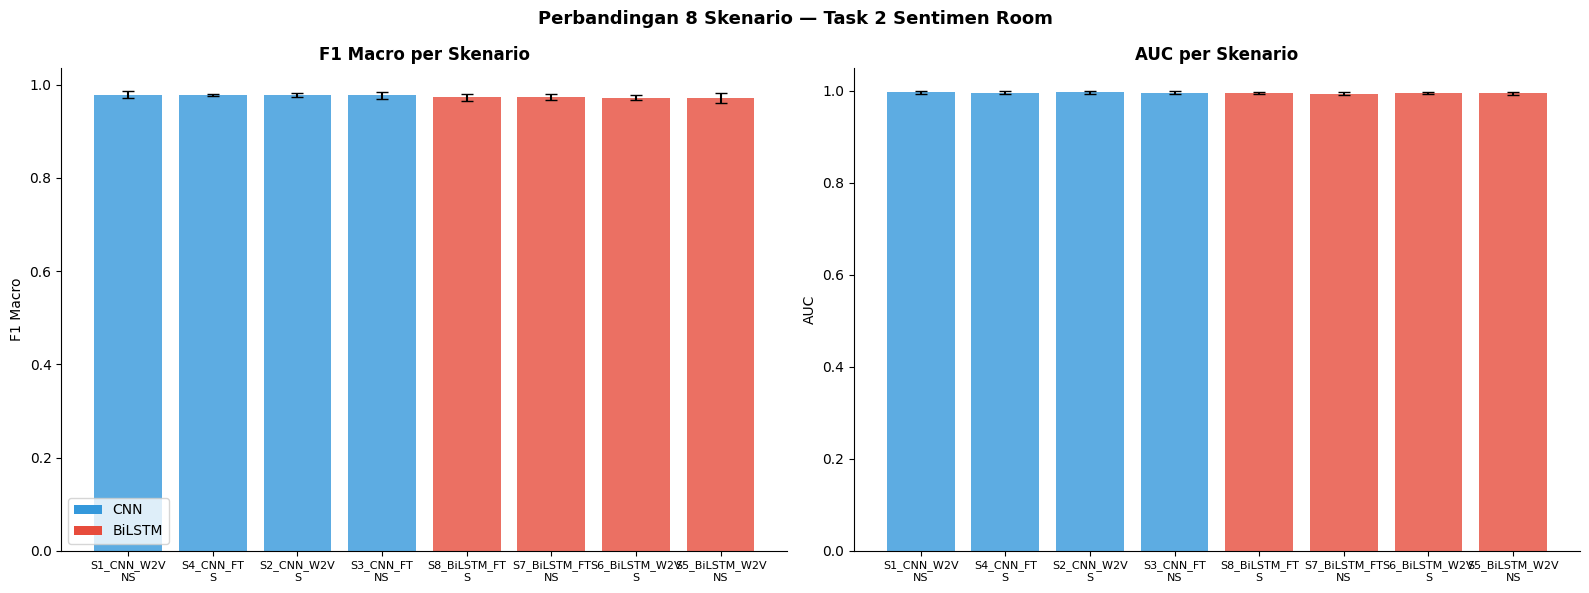

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#3498db' if 'CNN' in s else '#e74c3c'
          for s in df_rekap['skenario']]
labels_short = [s.replace('Skenario','S').replace('_NonStem','\nNS').replace('_Stem','\nS')
                for s in df_rekap['skenario']]

# F1 Macro
bars = axes[0].bar(range(len(df_rekap)), df_rekap['avg_f1_macro'],
                   color=colors, alpha=0.8)
axes[0].errorbar(range(len(df_rekap)), df_rekap['avg_f1_macro'],
                 yerr=df_rekap['std_f1_macro'], fmt='none',
                 color='black', capsize=4)
axes[0].set_xticks(range(len(df_rekap)))
axes[0].set_xticklabels(labels_short, fontsize=8)
axes[0].set_title('F1 Macro per Skenario', fontweight='bold')
axes[0].set_ylabel('F1 Macro')
axes[0].spines[['top','right']].set_visible(False)

# AUC
axes[1].bar(range(len(df_rekap)), df_rekap['avg_auc'],
            color=colors, alpha=0.8)
axes[1].errorbar(range(len(df_rekap)), df_rekap['avg_auc'],
                 yerr=df_rekap['std_auc'], fmt='none',
                 color='black', capsize=4)
axes[1].set_xticks(range(len(df_rekap)))
axes[1].set_xticklabels(labels_short, fontsize=8)
axes[1].set_title('AUC per Skenario', fontweight='bold')
axes[1].set_ylabel('AUC')
axes[1].spines[['top','right']].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='CNN'),
    Patch(facecolor='#e74c3c', label='BiLSTM')
]
axes[0].legend(handles=legend_elements)

plt.suptitle('Perbandingan 8 Skenario — Task 2 Sentimen Room',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'perbandingan_skenario_Task2.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 11. Dummy Classifier

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, classification_report

# ============================================================
# DUMMY CLASSIFIER BASELINE — Task 2 Sentimen Room
# (LABEL_COL sesuai task masing-masing)
# ============================================================

print('='*60)
print('  DUMMY CLASSIFIER BASELINE')
print('  Strategi: majority class (tebak kelas terbanyak)')
print('='*60)

# Data train dan test sudah ada dari cell sebelumnya
# y_train = label training
# y_test  = label test (load dulu kalau belum)

# Kalau y_test belum ada, load dulu:
df_test  = pd.read_csv(SPLIT_DIR + 'df_test_Task2_Room.csv')
y_test   = df_test[LABEL_COL].values

print(f'\n  Distribusi data train:')
print(f'  Positif : {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)')
print(f'  Negatif : {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)')

print(f'\n  Distribusi data test:')
print(f'  Positif : {(y_test==1).sum()} ({(y_test==1).mean()*100:.1f}%)')
print(f'  Negatif : {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)')

# Strategi 1: most_frequent (tebak majority class)
dummy_majority = DummyClassifier(strategy='most_frequent')
dummy_majority.fit(y_train.reshape(-1,1), y_train)
y_pred_majority = dummy_majority.predict(y_test.reshape(-1,1))

# Strategi 2: stratified (tebak random sesuai proporsi)
dummy_stratified = DummyClassifier(strategy='stratified',
                                    random_state=42)
dummy_stratified.fit(y_train.reshape(-1,1), y_train)
y_pred_stratified = dummy_stratified.predict(y_test.reshape(-1,1))

# Hitung F1
f1_majority   = f1_score(y_test, y_pred_majority,
                          average='macro', zero_division=0)
f1_stratified = f1_score(y_test, y_pred_stratified,
                          average='macro', zero_division=0)

print(f'\n  Hasil Dummy Classifier:')
print(f'  {"Strategi":<20} {"F1 Macro":>10}')
print(f'  {"-"*32}')
print(f'  {"Most Frequent":<20} {f1_majority:>10.4f}')
print(f'  {"Stratified":<20} {f1_stratified:>10.4f}')

print(f'\n  Classification Report — Most Frequent:')
print(classification_report(
    y_test, y_pred_majority,
    target_names=['Negatif', 'Positif'],
    zero_division=0
))

print('='*60)
print('  PERBANDINGAN MODEL vs DUMMY')
print('='*60)

# Ambil F1 terbaik dari rekap kalau sudah ada
try:
    df_rekap = pd.read_csv(OUTPUT_DIR + 'rekap_Task2_semua_skenario.csv')
    best_f1  = df_rekap['avg_f1_macro'].max()
    best_sk  = df_rekap.loc[df_rekap['avg_f1_macro'].idxmax(), 'skenario']
    print(f'  Model terbaik : {best_sk}')
    print(f'  F1 model      : {best_f1:.4f}')
    print(f'  F1 dummy      : {f1_majority:.4f}')
    print(f'  Selisih       : +{best_f1 - f1_majority:.4f}')
    print(f'\n  → Model {((best_f1/max(f1_majority,0.0001))-1)*100:.0f}% '
          f'lebih baik dari dummy!')
except:
    print(f'  F1 dummy (majority)   : {f1_majority:.4f}')
    print(f'  F1 dummy (stratified) : {f1_stratified:.4f}')
    print(f'  → Bandingkan dengan F1 model setelah training selesai')

print('='*60)

  DUMMY CLASSIFIER BASELINE
  Strategi: majority class (tebak kelas terbanyak)

  Distribusi data train:
  Positif : 1435 (46.8%)
  Negatif : 1631 (53.2%)

  Distribusi data test:
  Positif : 160 (46.9%)
  Negatif : 181 (53.1%)

  Hasil Dummy Classifier:
  Strategi               F1 Macro
  --------------------------------
  Most Frequent            0.3467
  Stratified               0.4552

  Classification Report — Most Frequent:
              precision    recall  f1-score   support

     Negatif       0.53      1.00      0.69       181
     Positif       0.00      0.00      0.00       160

    accuracy                           0.53       341
   macro avg       0.27      0.50      0.35       341
weighted avg       0.28      0.53      0.37       341

  PERBANDINGAN MODEL vs DUMMY
  Model terbaik : Skenario1_CNN_W2V_NonStem
  F1 model      : 0.9784
  F1 dummy      : 0.3467
  Selisih       : +0.6317

  → Model 182% lebih baik dari dummy!
